# Сходимость, внутреннее поле, ЭПР и верификация Ми

Воспроизводимый вычислительный блокнот для последующих экспериментов главы 4. Численные алгоритмы реализованы в пакетах `em3d.experiments.stationary_validation` и `experiments.em_validation`; блокнот задаёт конфигурацию, запускает стенд и показывает сохранённые таблицы и рисунки.

Экспериментальный протокол разделяет четыре уровня: сравнение решателей по истинной невязке и числу действий оператора; количественное сопоставление полей; абсолютную и нормированную ЭПР; независимую верификацию на аналитическом решении Ми.

## 1. Конфигурация и воспроизводимость

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "experiments").is_dir() and (REPO_ROOT.parent / "experiments").is_dir():
    REPO_ROOT = REPO_ROOT.parent
for candidate in (REPO_ROOT, REPO_ROOT / "src"):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from experiments.em_validation import ValidationStudyConfig, run_validation_suite


In [2]:
MODE = "quick"          # заменить на "publication" для итоговой серии
DEVICE = "cpu"          # "cpu", "cuda" или "auto"
RUN_SOLVER_STUDY = True
RUN_MIE_STUDY = True
RENDER_FIGURES = True

OUTPUT_ROOT = REPO_ROOT / "experiments" / "outputs" / "em_solver_farfield_validation_notebook"
factory = ValidationStudyConfig.quick if MODE == "quick" else ValidationStudyConfig.publication
config = factory(output_root=OUTPUT_ROOT, device=DEVICE)
config


ValidationStudyConfig(mode='quick', runtime=RuntimeConfig(device='cpu', precision='double'), solver=SolverStudyConfig(case_keys=('anisotropic_ellipsoid',), grid_size=8, coarse_size=3, coarse_size_overrides=(), solver_names=('SIM', 'BiCGStab', 'TwoStep'), max_iter=80, rtol=1e-05, divergence_guard=1000000.0, rcs_n_phi=36, rcs_planes=('xz',), save_solutions=True), mie=MieStudyConfig(grid_sizes=(6, 8), eps_values=((1.2+0j), (1.5+0j)), k0a_values=(0.5, 1.0), radius=0.25, domain_length=1.0, solver_names=('SIM', 'BiCGStab', 'TwoStep'), sim_coarse_size=3, max_iter=80, rtol=1e-05, divergence_guard=1000000.0, rcs_n_phi=36, rcs_plane='xz', field_reference_grids=(6,), compare_farfield_backends_on_smallest_grid=True, save_solutions=False), output_root=PosixPath('/mnt/data/em3d_ch4_work/experiments/outputs/em_solver_farfield_validation_notebook'))

## 2. Пакетный запуск полного протокола V1–V4

In [3]:
study = run_validation_suite(
    config,
    include_solver_study=RUN_SOLVER_STUDY,
    include_mie_study=RUN_MIE_STUDY,
    render_figures=RENDER_FIGURES,
)
study


ValidationSuiteResult(config=ValidationStudyConfig(mode='quick', runtime=RuntimeConfig(device='cpu', precision='double'), solver=SolverStudyConfig(case_keys=('anisotropic_ellipsoid',), grid_size=8, coarse_size=3, coarse_size_overrides=(), solver_names=('SIM', 'BiCGStab', 'TwoStep'), max_iter=80, rtol=1e-05, divergence_guard=1000000.0, rcs_n_phi=36, rcs_planes=('xz',), save_solutions=True), mie=MieStudyConfig(grid_sizes=(6, 8), eps_values=((1.2+0j), (1.5+0j)), k0a_values=(0.5, 1.0), radius=0.25, domain_length=1.0, solver_names=('SIM', 'BiCGStab', 'TwoStep'), sim_coarse_size=3, max_iter=80, rtol=1e-05, divergence_guard=1000000.0, rcs_n_phi=36, rcs_plane='xz', field_reference_grids=(6,), compare_farfield_backends_on_smallest_grid=True, save_solutions=False), output_root=PosixPath('/mnt/data/em3d_ch4_work/experiments/outputs/em_solver_farfield_validation_notebook')), stationary_cases=(StationaryCaseStudyResult(definition=SpectralCaseDefinition(key='anisotropic_ellipsoid', title='Анизотропн

In [4]:
def read_table(name: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_ROOT / "tables" / name)

manifest = json.loads((OUTPUT_ROOT / "manifest.json").read_text(encoding="utf-8"))
display({
    "status": manifest["status"],
    "schema": manifest["schema"],
    "git_commit": manifest["git_commit"],
    "em3d_version": manifest["em3d_version"],
    "artifact_count": len(manifest["artifacts"]),
})
display(read_table("FINAL_experimental_protocol.csv"))


{'status': 'complete',
 'schema': 'em3d-stationary-validation-artifacts-v1',
 'git_commit': '38b099c38dfb50df068628077c622af40d544c4c',
 'em3d_version': '0.5.0',
 'artifact_count': 127}

,experiment,purpose,executed
0,V1,solver comparison by true residual and operato...,True
1,V2,field agreement and shared-scale slice diagnos...,True
2,V3,absolute and normalized RCS agreement between ...,True
3,V4,Mie verification with nominal and effective sp...,True


## 3. V1: сравнение решателей по истинной невязке и действиям оператора

In [5]:
solver_runs = read_table("solver_runs.csv")
display(solver_runs[[
    "case_key", "solver_name", "status", "qualified",
    "iterations", "matvec_count", "rmatvec_count",
    "operator_action_count", "true_final_residual", "elapsed_seconds",
]])


,case_key,solver_name,status,qualified,iterations,matvec_count,rmatvec_count,operator_action_count,true_final_residual,elapsed_seconds
0,anisotropic_ellipsoid,SIM,converged,True,11,12,0,12,0.000010,0.004932
1,anisotropic_ellipsoid,BiCGStab,converged,True,3,7,0,7,0.000008,0.002893
2,anisotropic_ellipsoid,TwoStep,converged,True,10,21,10,31,0.000004,0.012448


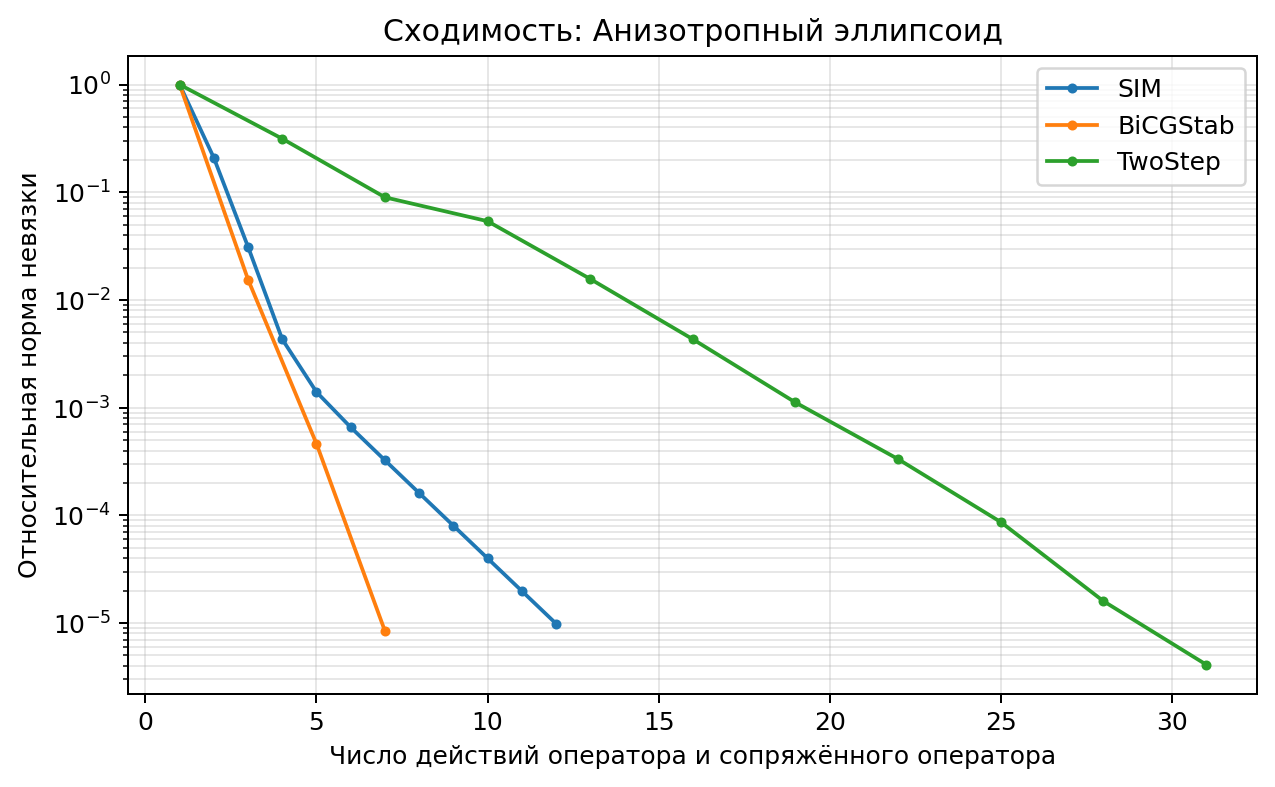

In [6]:
for path in sorted((OUTPUT_ROOT / "figures" / "solver").glob("*.png")):
    display(Image(filename=str(path)))


## 4. V2: согласованность внутренних полей

,case_key,candidate_solver,reference_solver,relative_l2,relative_linf,component_0_relative_l2,component_1_relative_l2,component_2_relative_l2
0,anisotropic_ellipsoid,SIM,BiCGStab,0.000008,0.000031,0.000007,0.000055,0.000054
1,anisotropic_ellipsoid,BiCGStab,BiCGStab,0.000000,0.000000,0.000000,0.000000,0.000000
2,anisotropic_ellipsoid,TwoStep,BiCGStab,0.000007,0.000024,0.000006,0.000059,0.000048


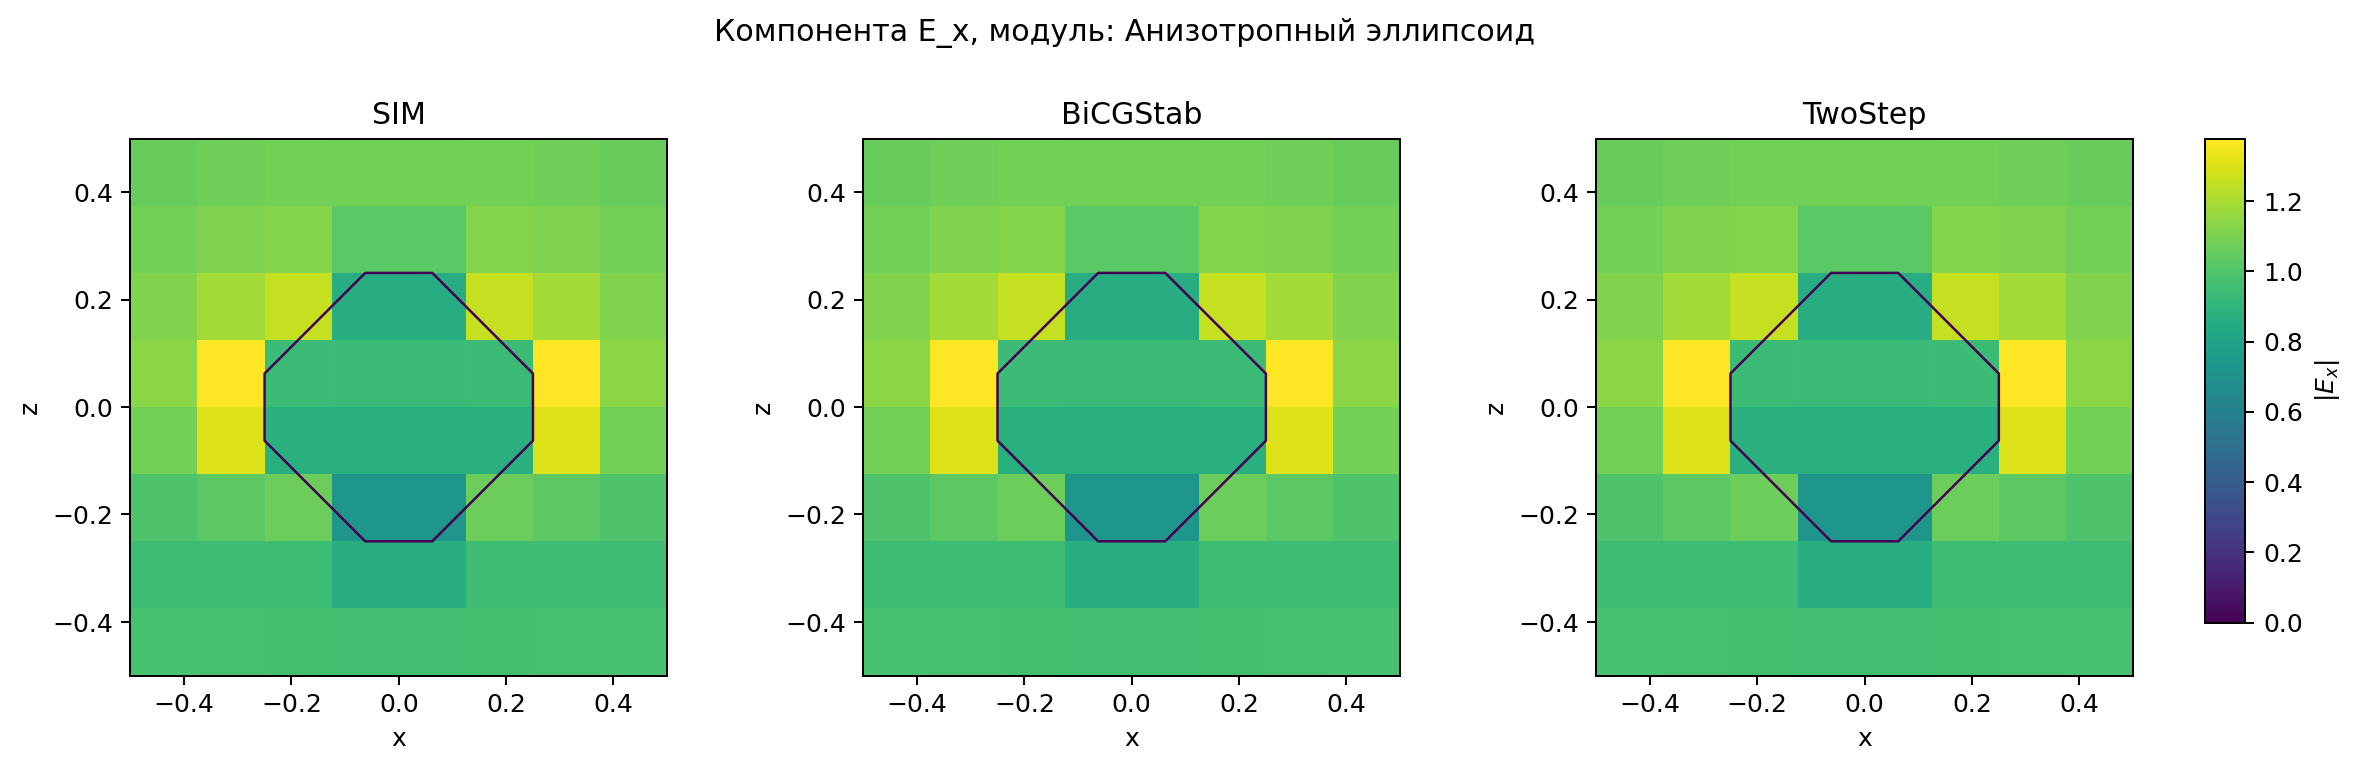

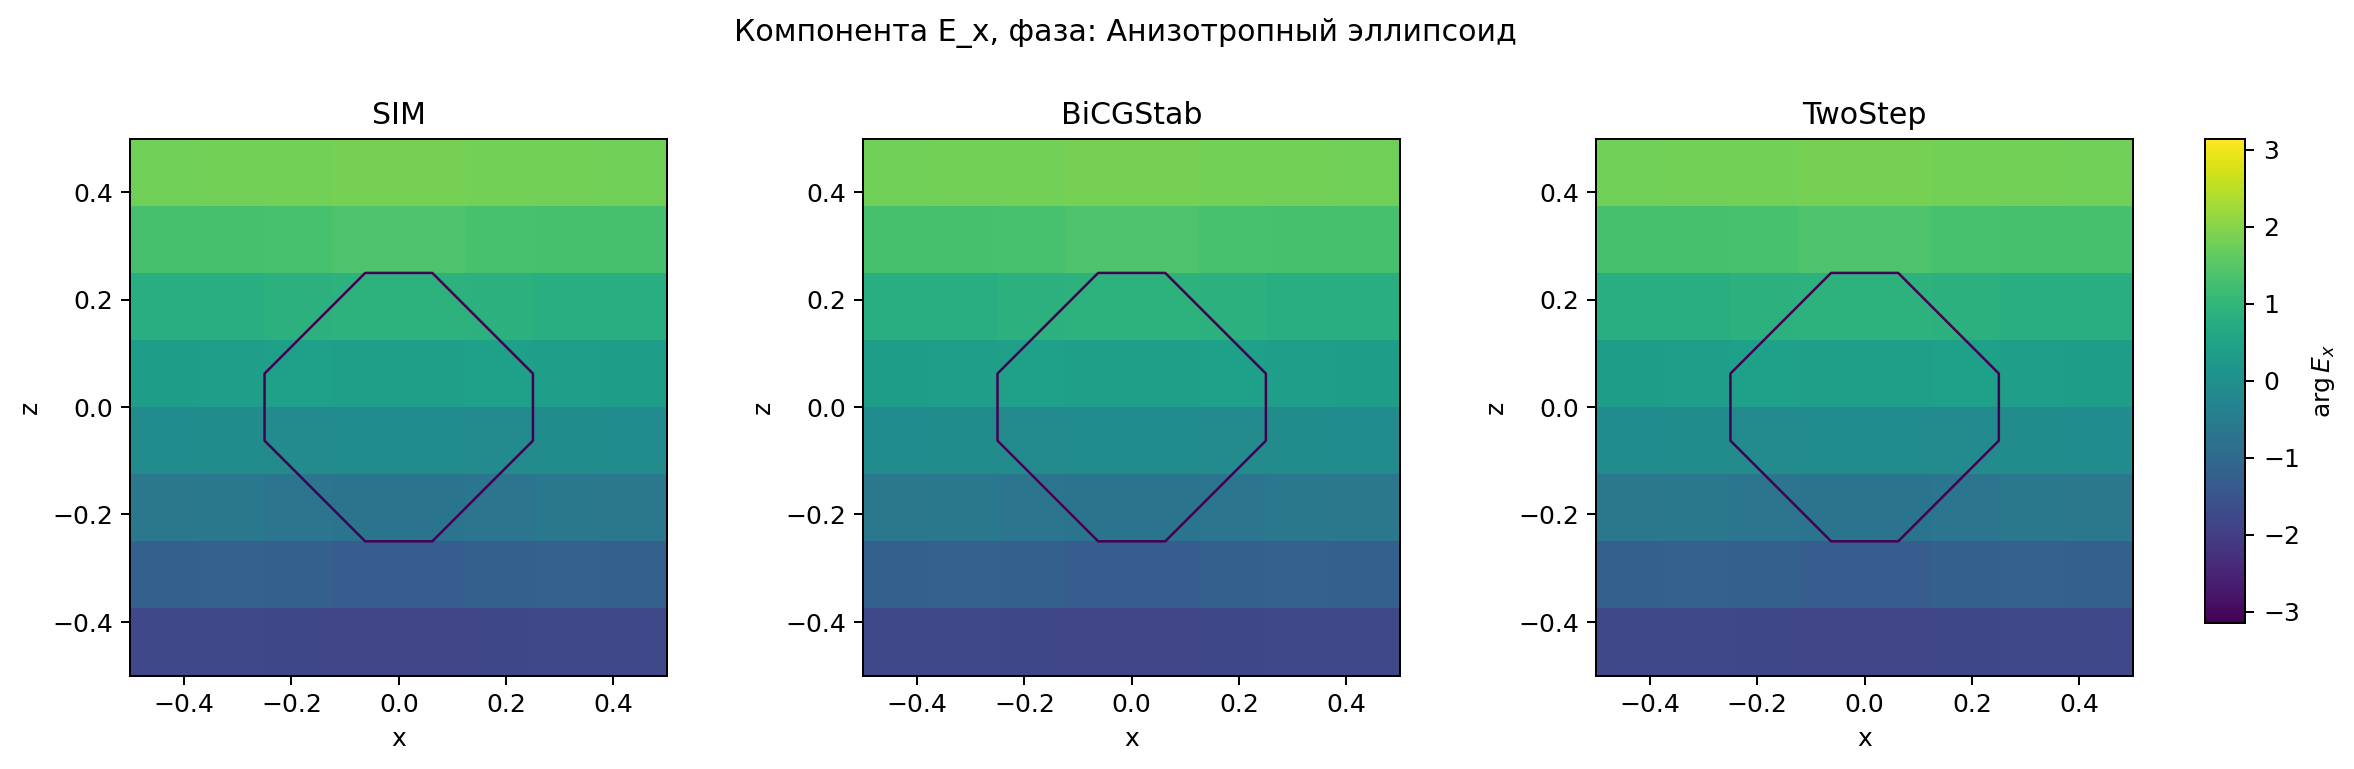

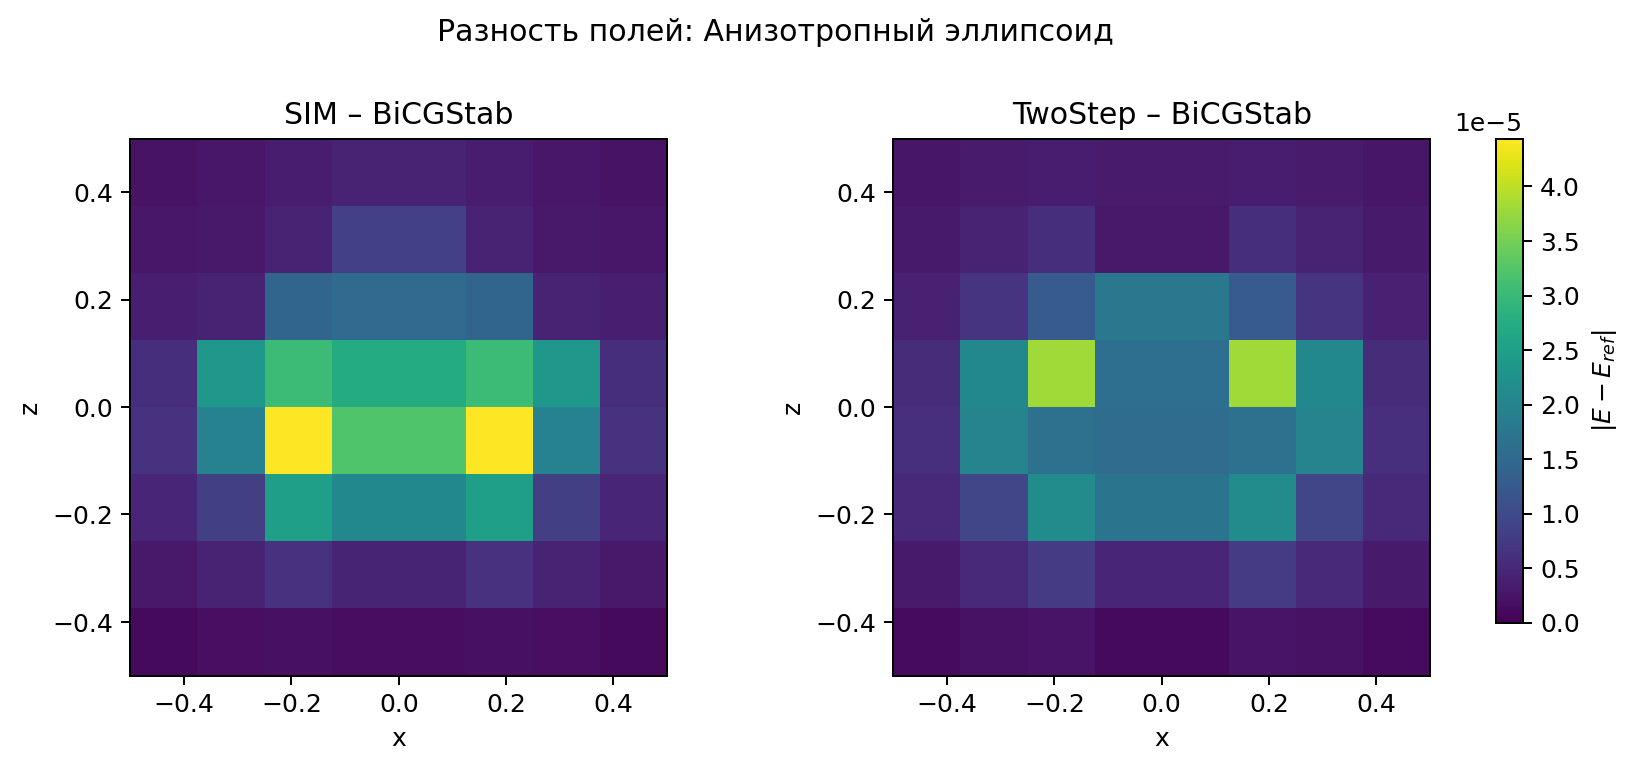

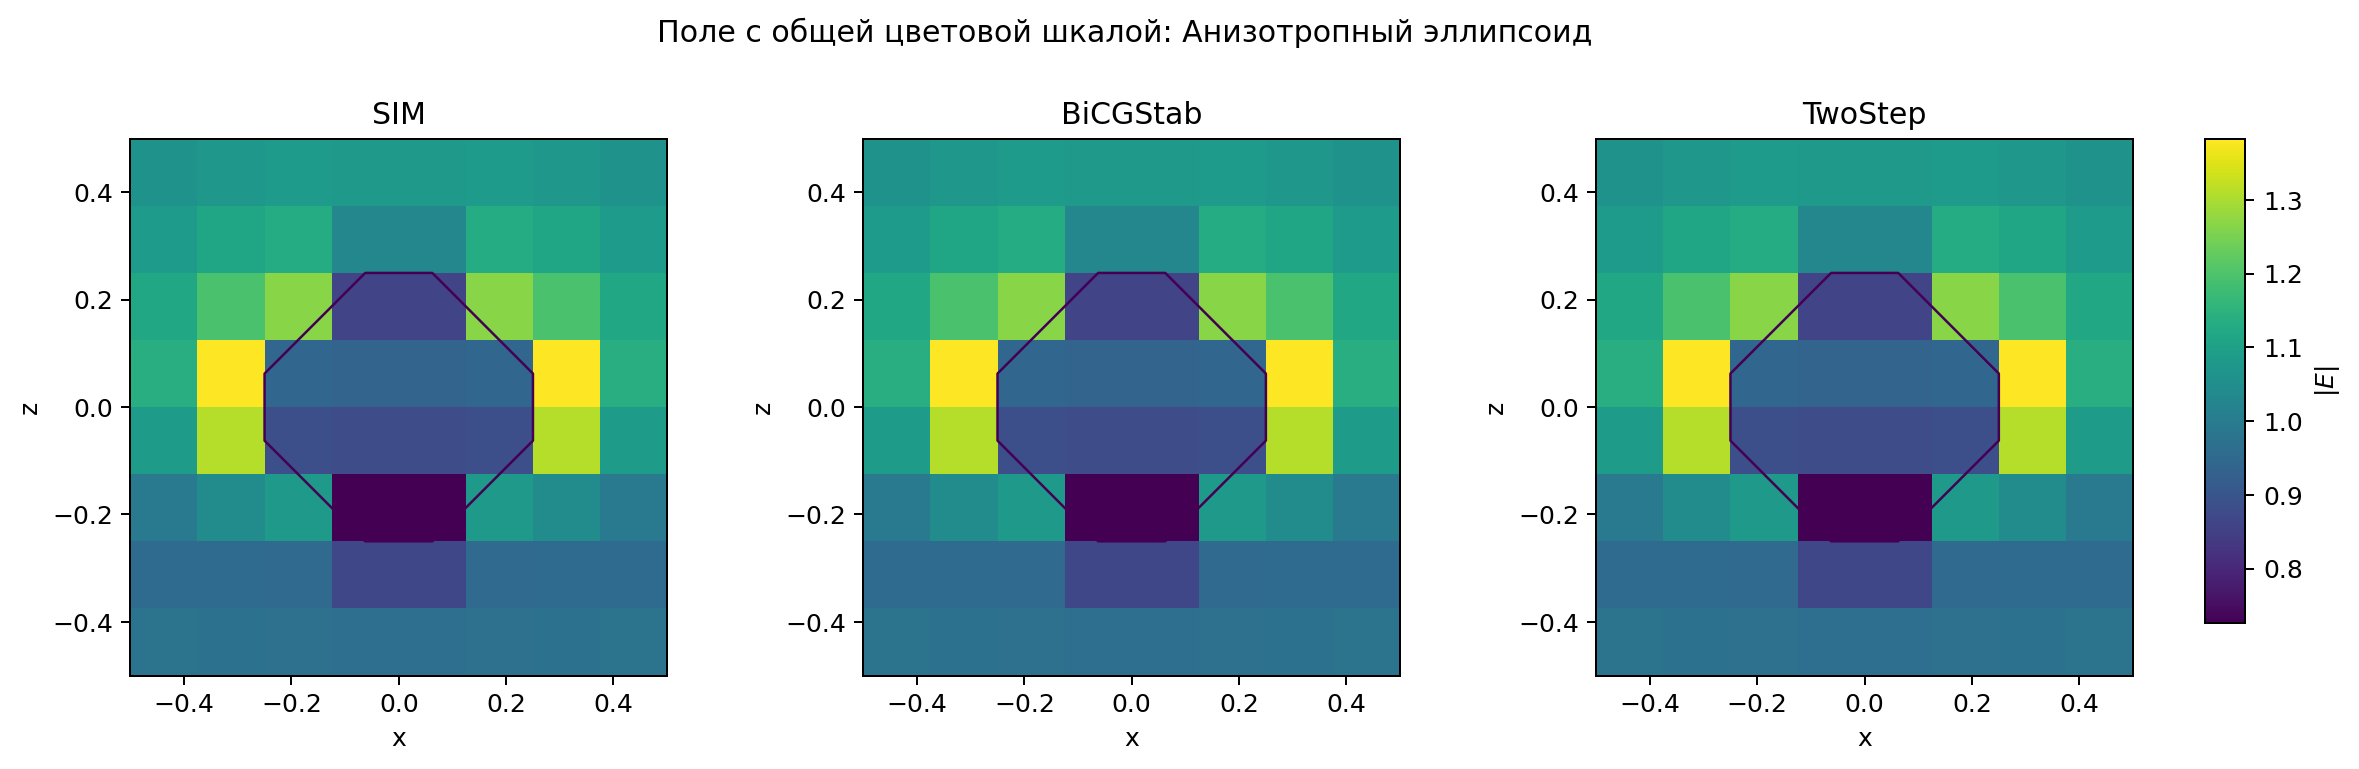

In [7]:
display(read_table("field_comparisons.csv"))
for path in sorted((OUTPUT_ROOT / "figures" / "field").glob("*.png")):
    display(Image(filename=str(path)))


## 5. V3: абсолютная и нормированная эффективная поверхность рассеяния

,case_key,candidate_solver,reference_solver,plane,normalized_l2,absolute_l2,absolute_linf,peak_ratio,integral_ratio,peak_angle_error_degrees
0,anisotropic_ellipsoid,SIM,BiCGStab,xz,0.000004,0.000007,0.000005,1.000004,1.000008,0.0
1,anisotropic_ellipsoid,BiCGStab,BiCGStab,xz,0.000000,0.000000,0.000000,1.000000,1.000000,0.0
2,anisotropic_ellipsoid,TwoStep,BiCGStab,xz,0.000002,0.000002,0.000002,1.000000,1.000002,0.0


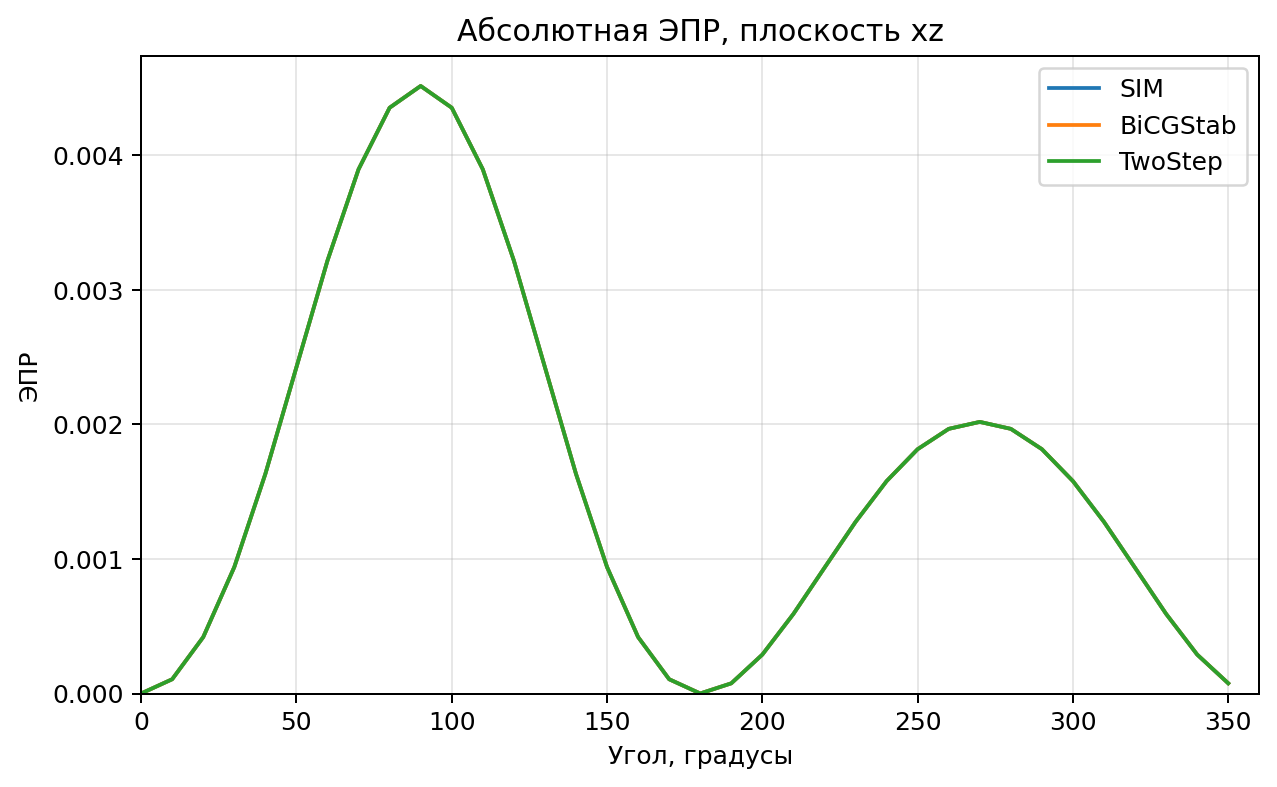

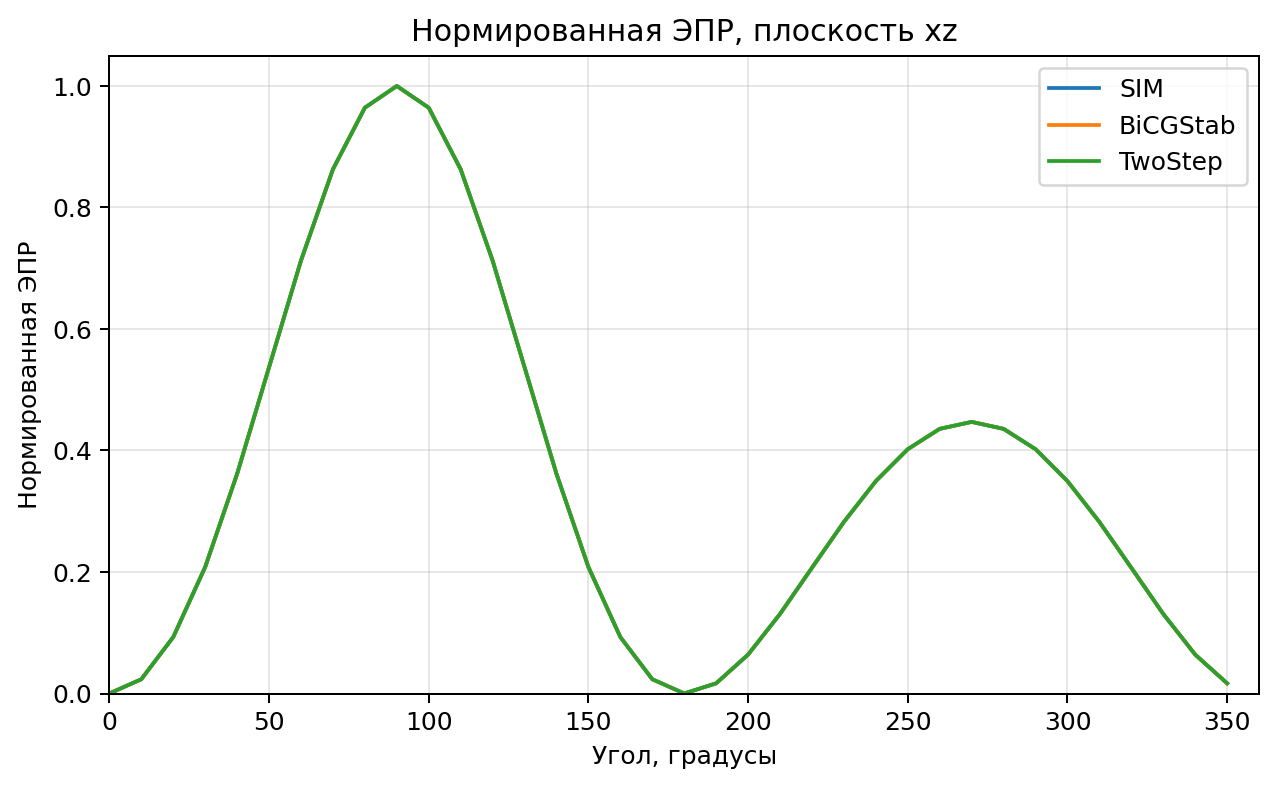

In [8]:
display(read_table("rcs_solver_comparisons.csv"))
for path in sorted((OUTPUT_ROOT / "figures" / "rcs").glob("*.png")):
    display(Image(filename=str(path)))


## 6. V4: верификация по аналитическому решению Ми

In [9]:
mie_runs = read_table("mie_solver_runs.csv")
mie_validation = read_table("mie_validation.csv")
mie_selected = read_table("mie_validation_selected.csv")
display(mie_runs[[
    "eps_real", "k0a", "grid_size", "solver_name", "status",
    "qualified", "operator_action_count", "true_final_residual",
]])
display(mie_validation[[
    "eps_real", "k0a", "grid_size", "solver_name",
    "relative_volume_error", "nominal_field_relative_l2", "nominal_scattered_field_outside_relative_l2",
    "nominal_rcs_normalized_l2", "nominal_rcs_absolute_l2",
    "nominal_rcs_peak_angle_error_degrees",
    "effective_rcs_normalized_l2", "farfield_backend_relative_l2",
]])


display(mie_selected)

,eps_real,k0a,grid_size,solver_name,status,qualified,operator_action_count,true_final_residual
0,1.2,0.5,6,SIM,converged,True,5,2.027718e-06
1,1.2,0.5,6,BiCGStab,converged,True,5,1.654740e-07
2,1.2,0.5,6,TwoStep,converged,True,13,1.452649e-06
3,1.2,0.5,8,SIM,converged,True,5,7.512903e-06
4,1.2,0.5,8,BiCGStab,converged,True,5,9.983753e-07
5,1.2,0.5,8,TwoStep,converged,True,16,1.085760e-06
6,1.2,1.0,6,SIM,converged,True,5,2.069054e-06
7,1.2,1.0,6,BiCGStab,converged,True,5,3.748907e-07
8,1.2,1.0,6,TwoStep,converged,True,16,1.144702e-06
9,1.2,1.0,8,SIM,converged,True,5,6.524431e-06


,eps_real,k0a,grid_size,solver_name,relative_volume_error,nominal_field_relative_l2,nominal_scattered_field_outside_relative_l2,nominal_rcs_normalized_l2,nominal_rcs_absolute_l2,nominal_rcs_peak_angle_error_degrees,effective_rcs_normalized_l2,farfield_backend_relative_l2
0,1.2,0.5,6,SIM,-0.434116,0.019414,1.646148,0.058081,0.671017,0.0,0.016107,0.001328
1,1.2,0.5,6,BiCGStab,-0.434116,0.019414,1.646142,0.058081,0.671015,0.0,0.016107,0.001328
2,1.2,0.5,6,TwoStep,-0.434116,0.019414,1.646142,0.058081,0.671015,0.0,0.016106,0.001328
3,1.2,0.5,8,SIM,-0.045070,NaN,NaN,0.009151,0.085552,0.0,0.005271,NaN
4,1.2,0.5,8,BiCGStab,-0.045070,NaN,NaN,0.009151,0.085543,0.0,0.005271,NaN
5,1.2,0.5,8,TwoStep,-0.045070,NaN,NaN,0.009151,0.085545,0.0,0.005271,NaN
6,1.2,1.0,6,SIM,-0.434116,0.037855,1.242783,0.179228,0.664710,0.0,0.046589,0.001847
7,1.2,1.0,6,BiCGStab,-0.434116,0.037855,1.242791,0.179229,0.664709,0.0,0.046590,0.001847
8,1.2,1.0,6,TwoStep,-0.434116,0.037856,1.242806,0.179228,0.664709,0.0,0.046589,0.001847
9,1.2,1.0,8,SIM,-0.045070,NaN,NaN,0.029563,0.090504,0.0,0.018325,NaN


,case_key,grid_size,eps_real,eps_imag,k0a,solver_name,qualified,true_final_residual,nominal_radius,effective_radius,represented_volume,exact_volume,relative_volume_error,farfield_backend_relative_l2,nominal_field_relative_l2,nominal_field_inside_relative_l2,nominal_field_outside_relative_l2,nominal_scattered_field_relative_l2,nominal_scattered_field_outside_relative_l2,nominal_rcs_normalized_l2,nominal_rcs_absolute_l2,nominal_rcs_absolute_linf,nominal_rcs_peak_ratio,nominal_rcs_integral_ratio,nominal_rcs_peak_angle_error_degrees,effective_field_relative_l2,effective_field_inside_relative_l2,effective_field_outside_relative_l2,effective_scattered_field_relative_l2,effective_scattered_field_outside_relative_l2,effective_rcs_normalized_l2,effective_rcs_absolute_l2,effective_rcs_absolute_linf,effective_rcs_peak_ratio,effective_rcs_integral_ratio,effective_rcs_peak_angle_error_degrees,selection_basis
0,mie_sphere_eps1p2_k0a0p5,6,1.2,0.0,0.5,BiCGStab,True,1.654740e-07,0.25,0.206783,0.037037,0.06545,-0.434116,0.001328,0.019414,0.018472,0.019445,1.277083,1.646142,0.058081,0.671015,0.683221,0.316779,0.330530,0.0,0.016865,0.017257,0.016851,1.343736,2.496990,0.016107,0.013764,0.018202,0.996292,1.008229,0.0,preferred_bicgstab
1,mie_sphere_eps1p2_k0a0p5,8,1.2,0.0,0.5,BiCGStab,True,9.983753e-07,0.25,0.246186,0.062500,0.06545,-0.045070,NaN,NaN,NaN,NaN,NaN,NaN,0.009151,0.085543,0.090710,0.909290,0.915249,0.0,NaN,NaN,NaN,NaN,NaN,0.005271,0.004230,0.005185,0.997803,1.001431,0.0,preferred_bicgstab
2,mie_sphere_eps1p2_k0a1,6,1.2,0.0,1.0,BiCGStab,True,3.748907e-07,0.25,0.206783,0.037037,0.06545,-0.434116,0.001847,0.037855,0.032185,0.038050,1.211333,1.242791,0.179229,0.664709,0.689122,0.310878,0.357393,0.0,0.028634,0.022675,0.028826,1.448703,1.596420,0.046590,0.039558,0.040732,0.984883,1.021978,0.0,preferred_bicgstab
3,mie_sphere_eps1p2_k0a1,8,1.2,0.0,1.0,BiCGStab,True,2.234310e-06,0.25,0.246186,0.062500,0.06545,-0.045070,NaN,NaN,NaN,NaN,NaN,NaN,0.029563,0.090499,0.098697,0.901303,0.921708,0.0,NaN,NaN,NaN,NaN,NaN,0.018324,0.016854,0.016169,0.989539,1.002464,0.0,preferred_bicgstab
4,mie_sphere_eps1p5_k0a0p5,6,1.5,0.0,0.5,BiCGStab,True,4.819031e-06,0.25,0.206783,0.037037,0.06545,-0.434116,0.001329,0.044812,0.040403,0.044938,1.269023,1.638326,0.059715,0.675247,0.687413,0.312587,0.326407,0.0,0.038810,0.037708,0.038842,1.338208,2.490596,0.016584,0.012756,0.014744,0.992514,1.004508,0.0,preferred_bicgstab
5,mie_sphere_eps1p5_k0a0p5,8,1.5,0.0,0.5,BiCGStab,True,4.806337e-06,0.25,0.246186,0.062500,0.06545,-0.045070,NaN,NaN,NaN,NaN,NaN,NaN,0.011076,0.086933,0.092735,0.907265,0.914095,0.0,NaN,NaN,NaN,NaN,NaN,0.007130,0.005807,0.006120,0.996460,1.000995,0.0,preferred_bicgstab
6,mie_sphere_eps1p5_k0a1,6,1.5,0.0,1.0,BiCGStab,True,1.397214e-06,0.25,0.206783,0.037037,0.06545,-0.434116,0.001854,0.090880,0.072357,0.091468,1.202620,1.234546,0.181744,0.678651,0.701063,0.298937,0.343608,0.0,0.067738,0.048717,0.068270,1.440957,1.585635,0.047563,0.041030,0.034943,0.965057,1.000739,0.0,preferred_bicgstab
7,mie_sphere_eps1p5_k0a1,8,1.5,0.0,1.0,BiCGStab,True,7.121538e-07,0.25,0.246186,0.062500,0.06545,-0.045070,NaN,NaN,NaN,NaN,NaN,NaN,0.035590,0.104763,0.111998,0.888002,0.910141,0.0,NaN,NaN,NaN,NaN,NaN,0.024318,0.027563,0.023623,0.976377,0.991290,0.0,preferred_bicgstab


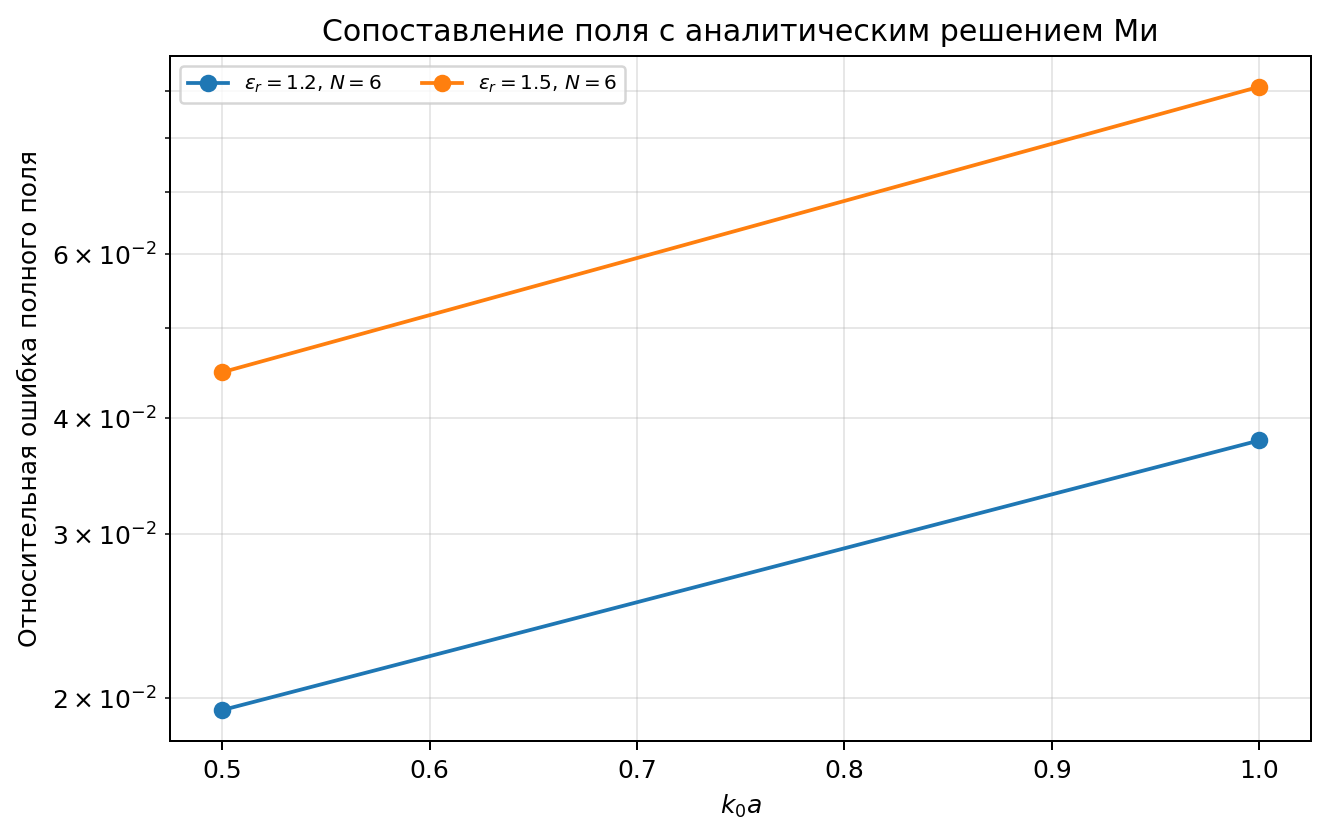

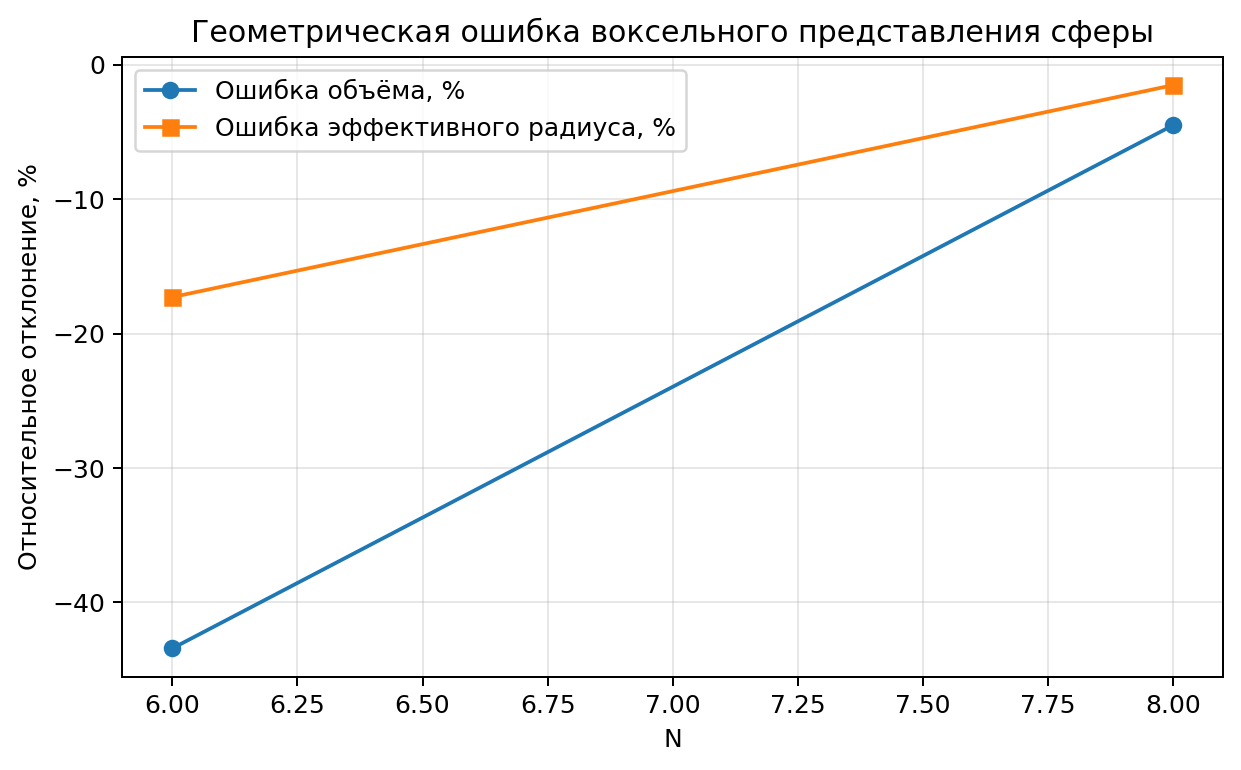

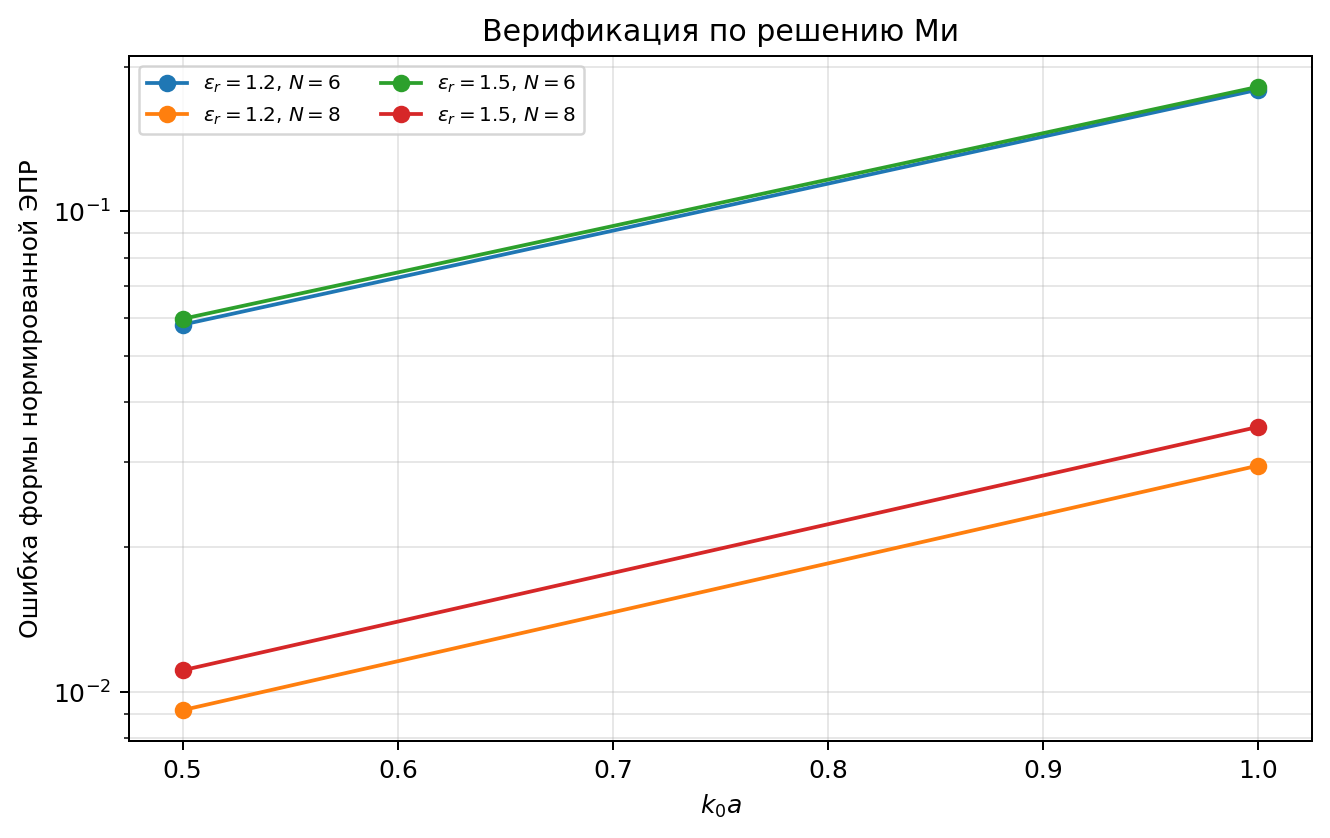

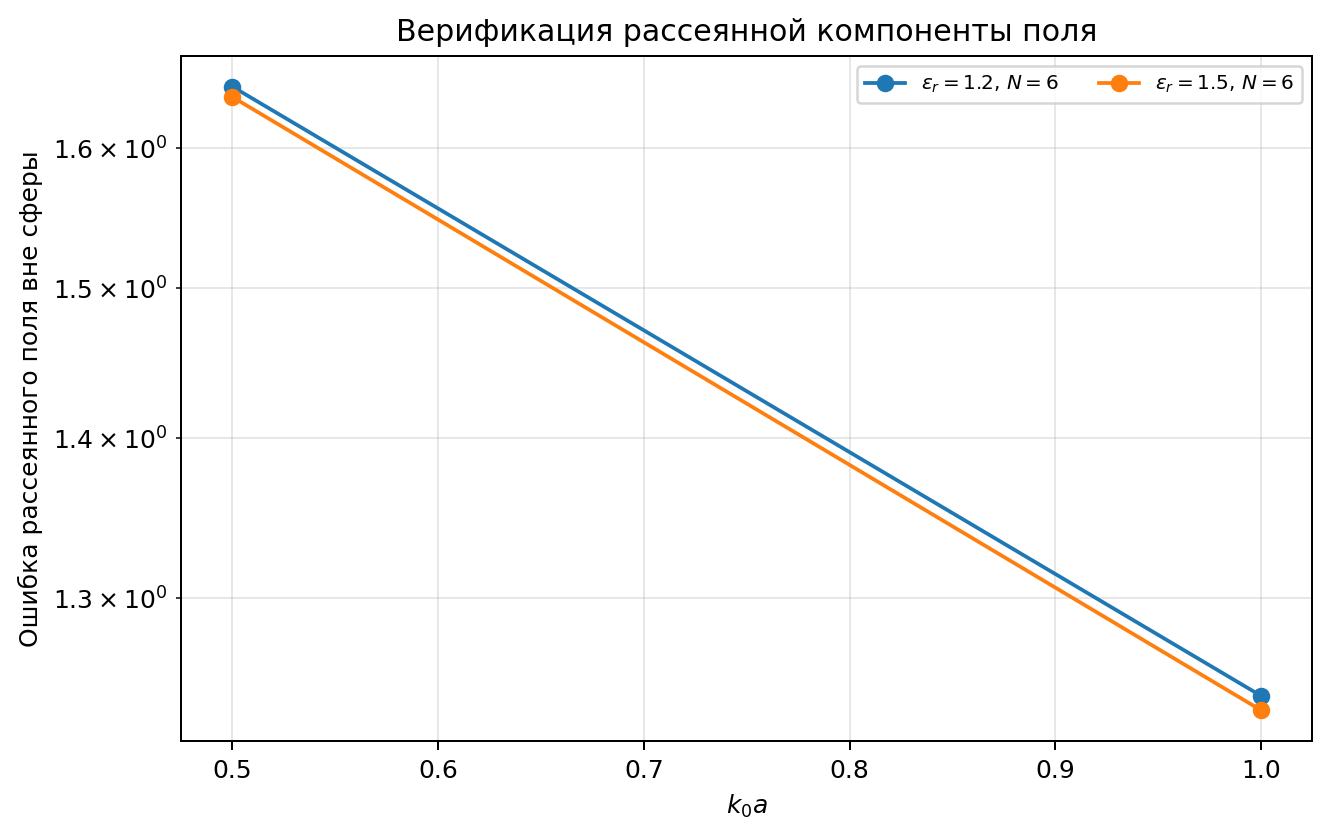

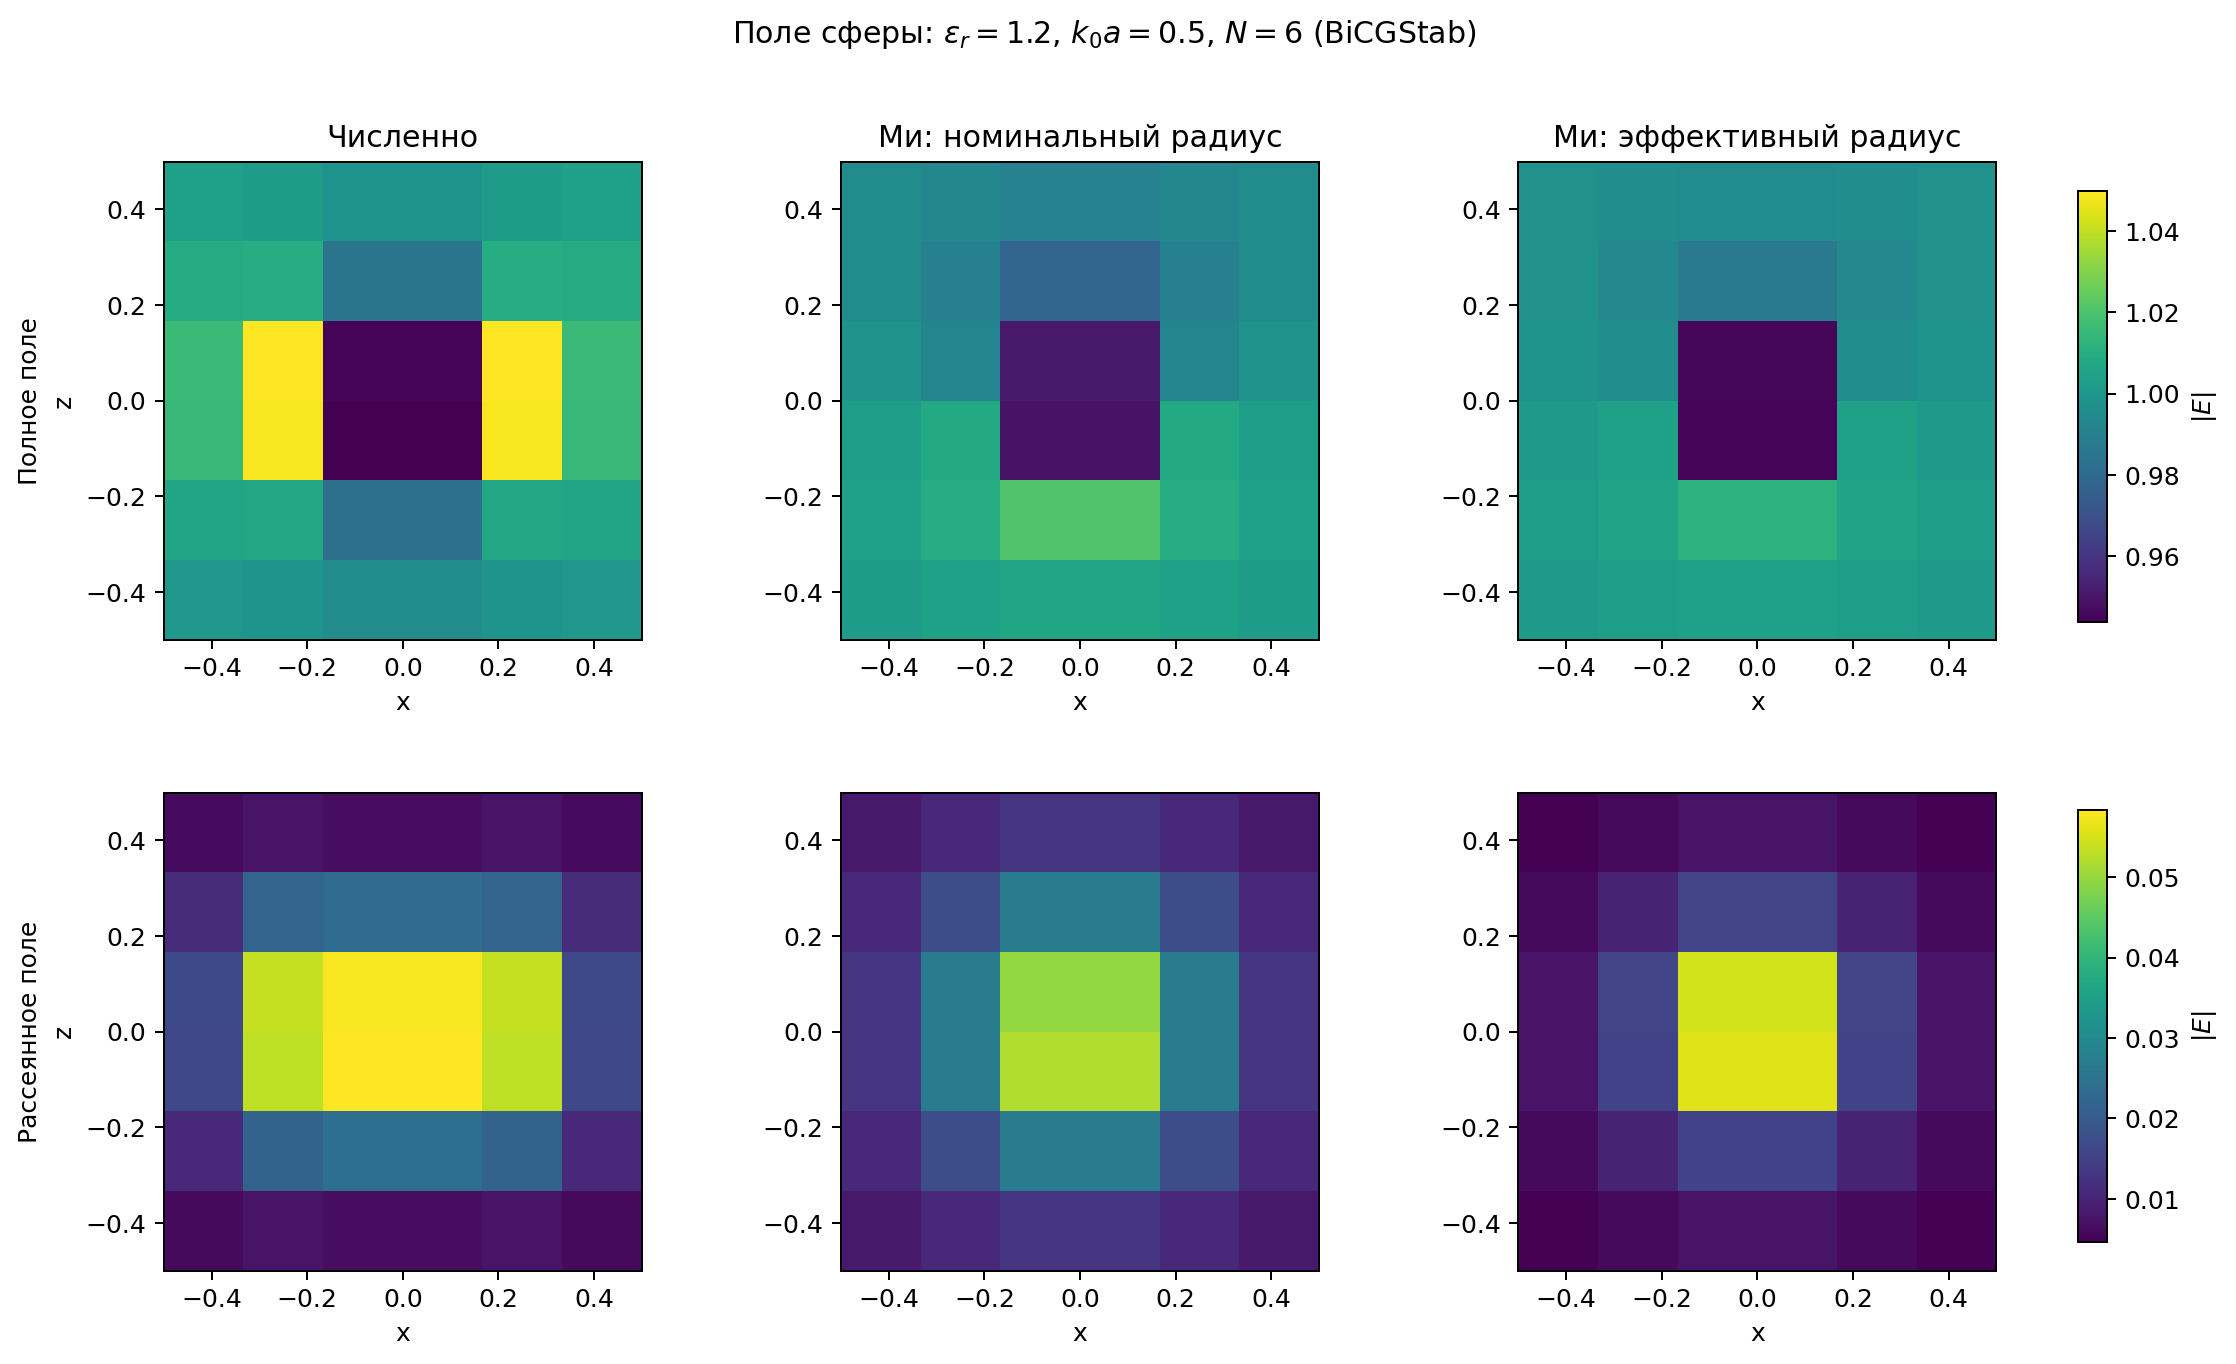

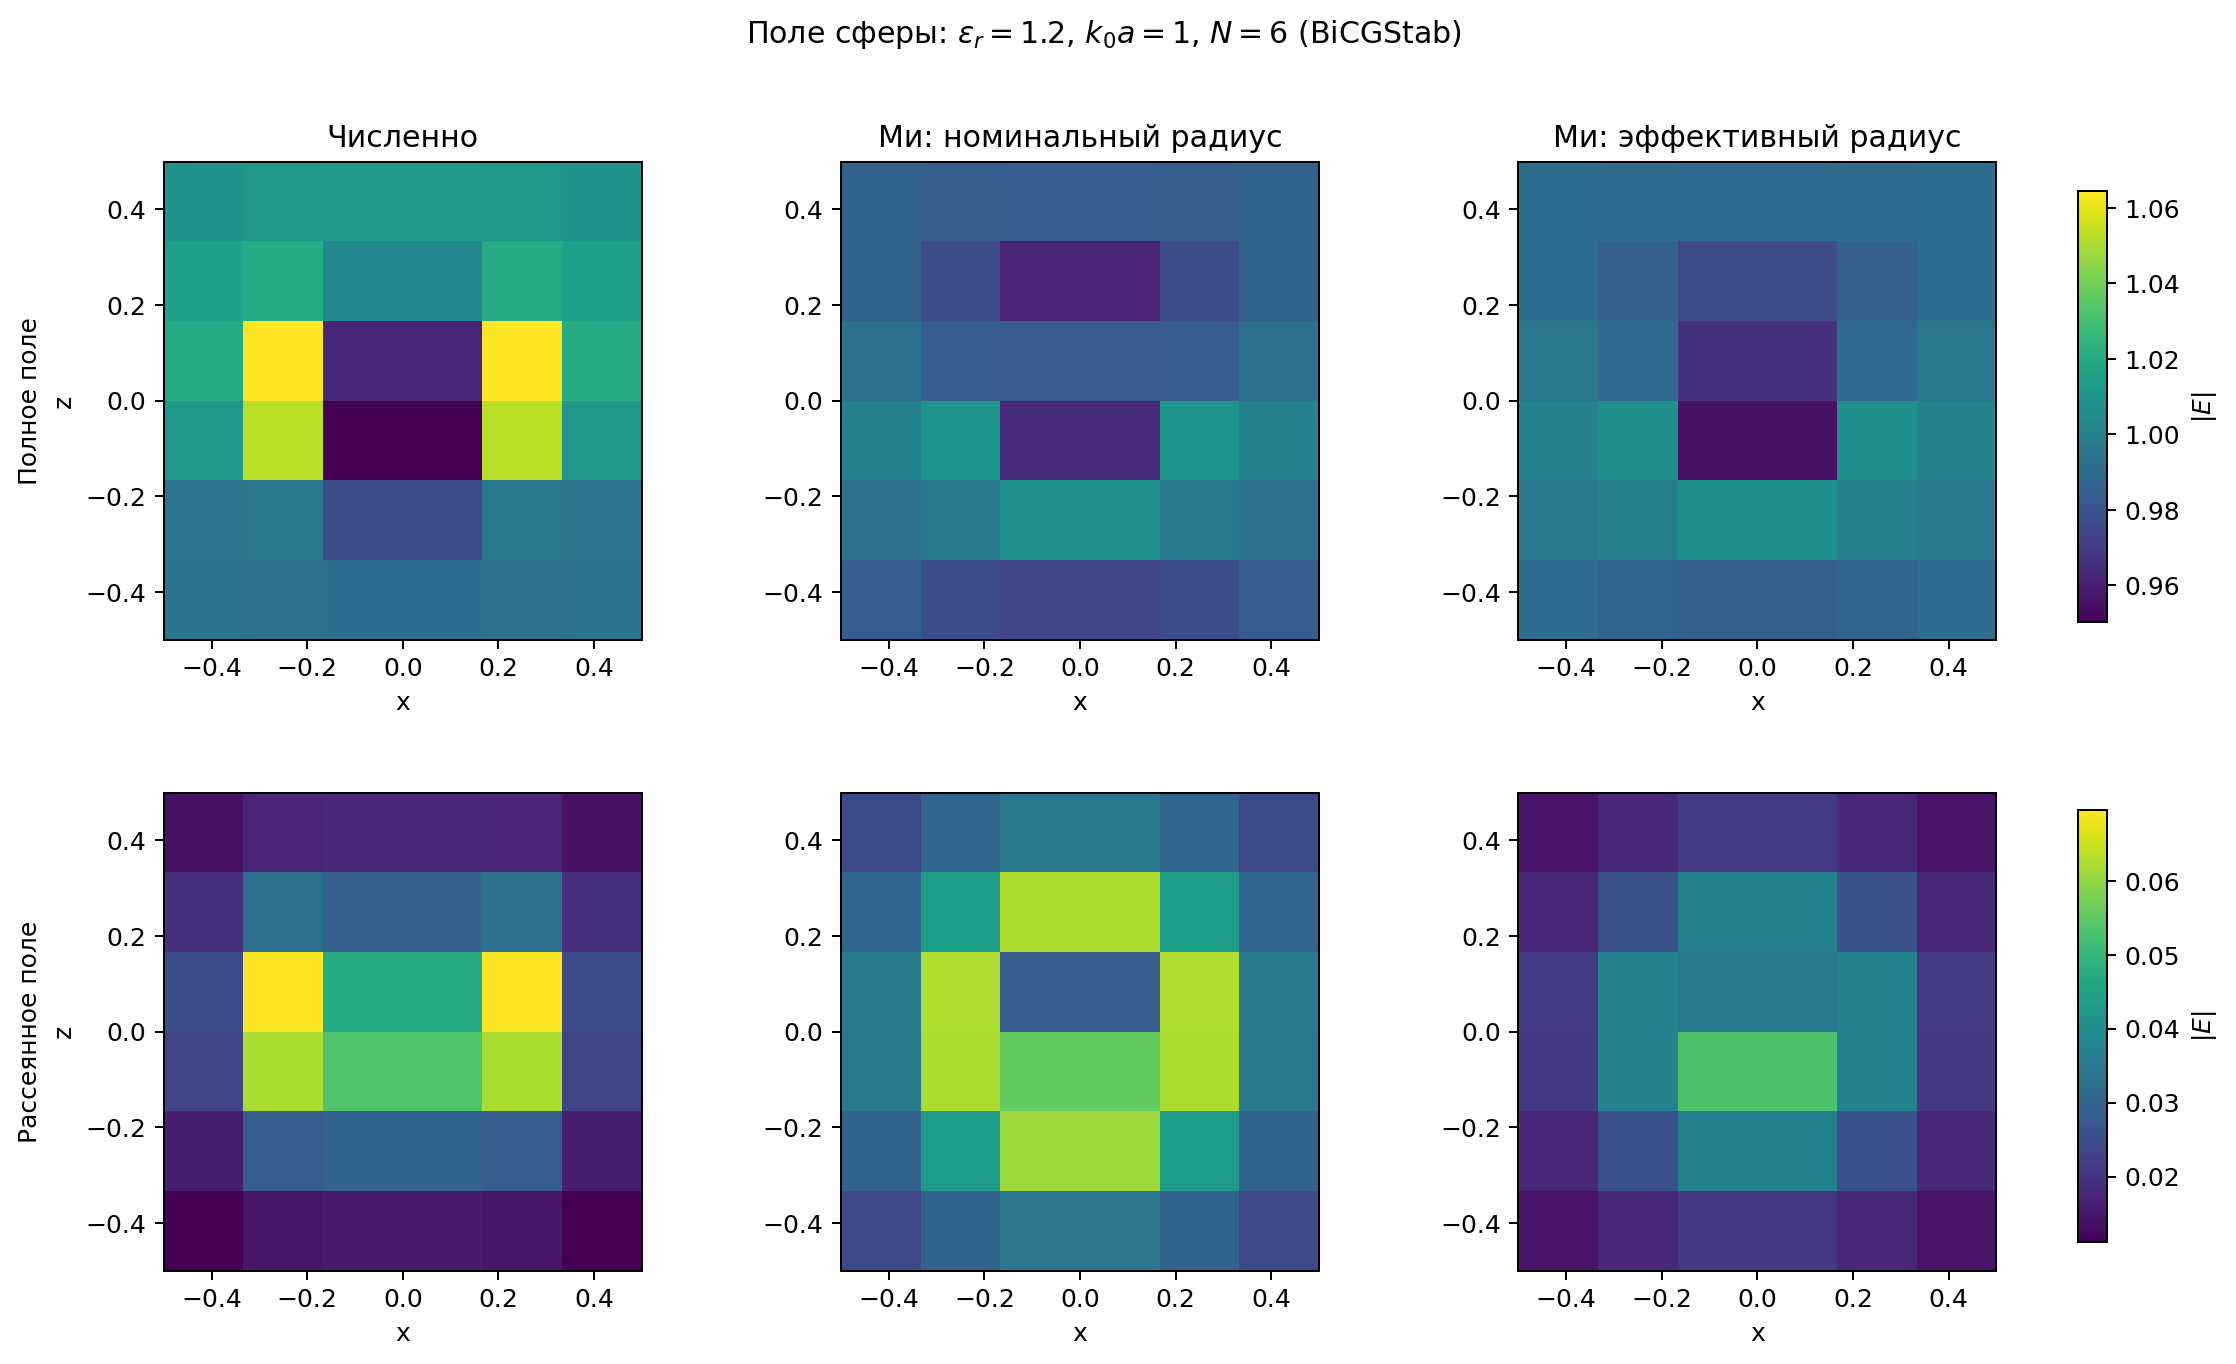

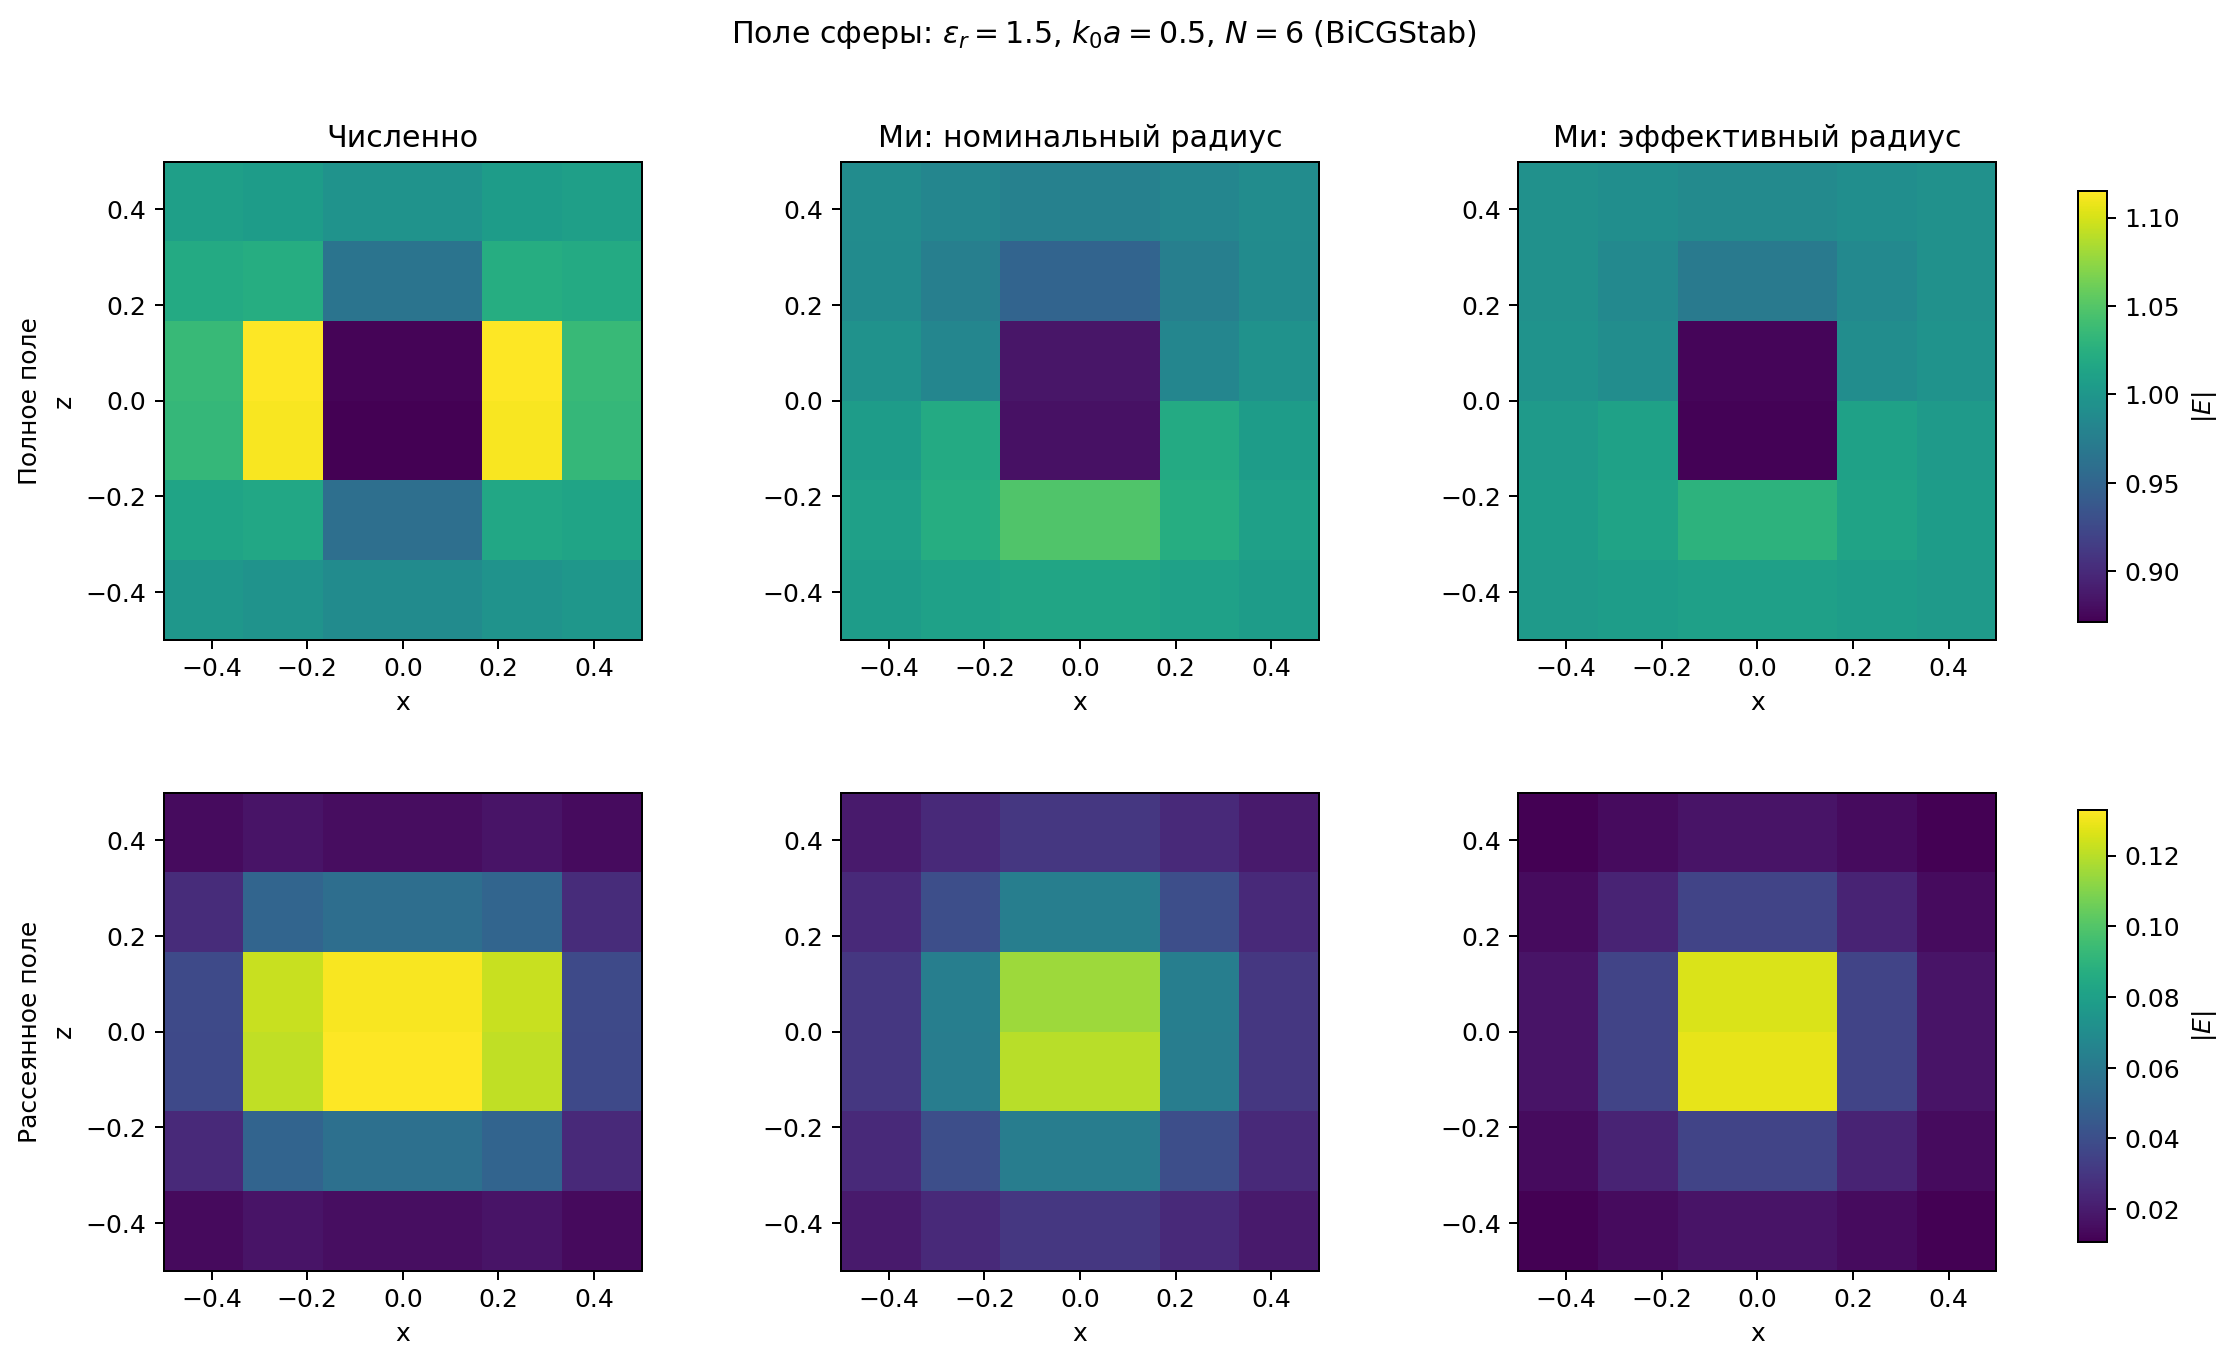

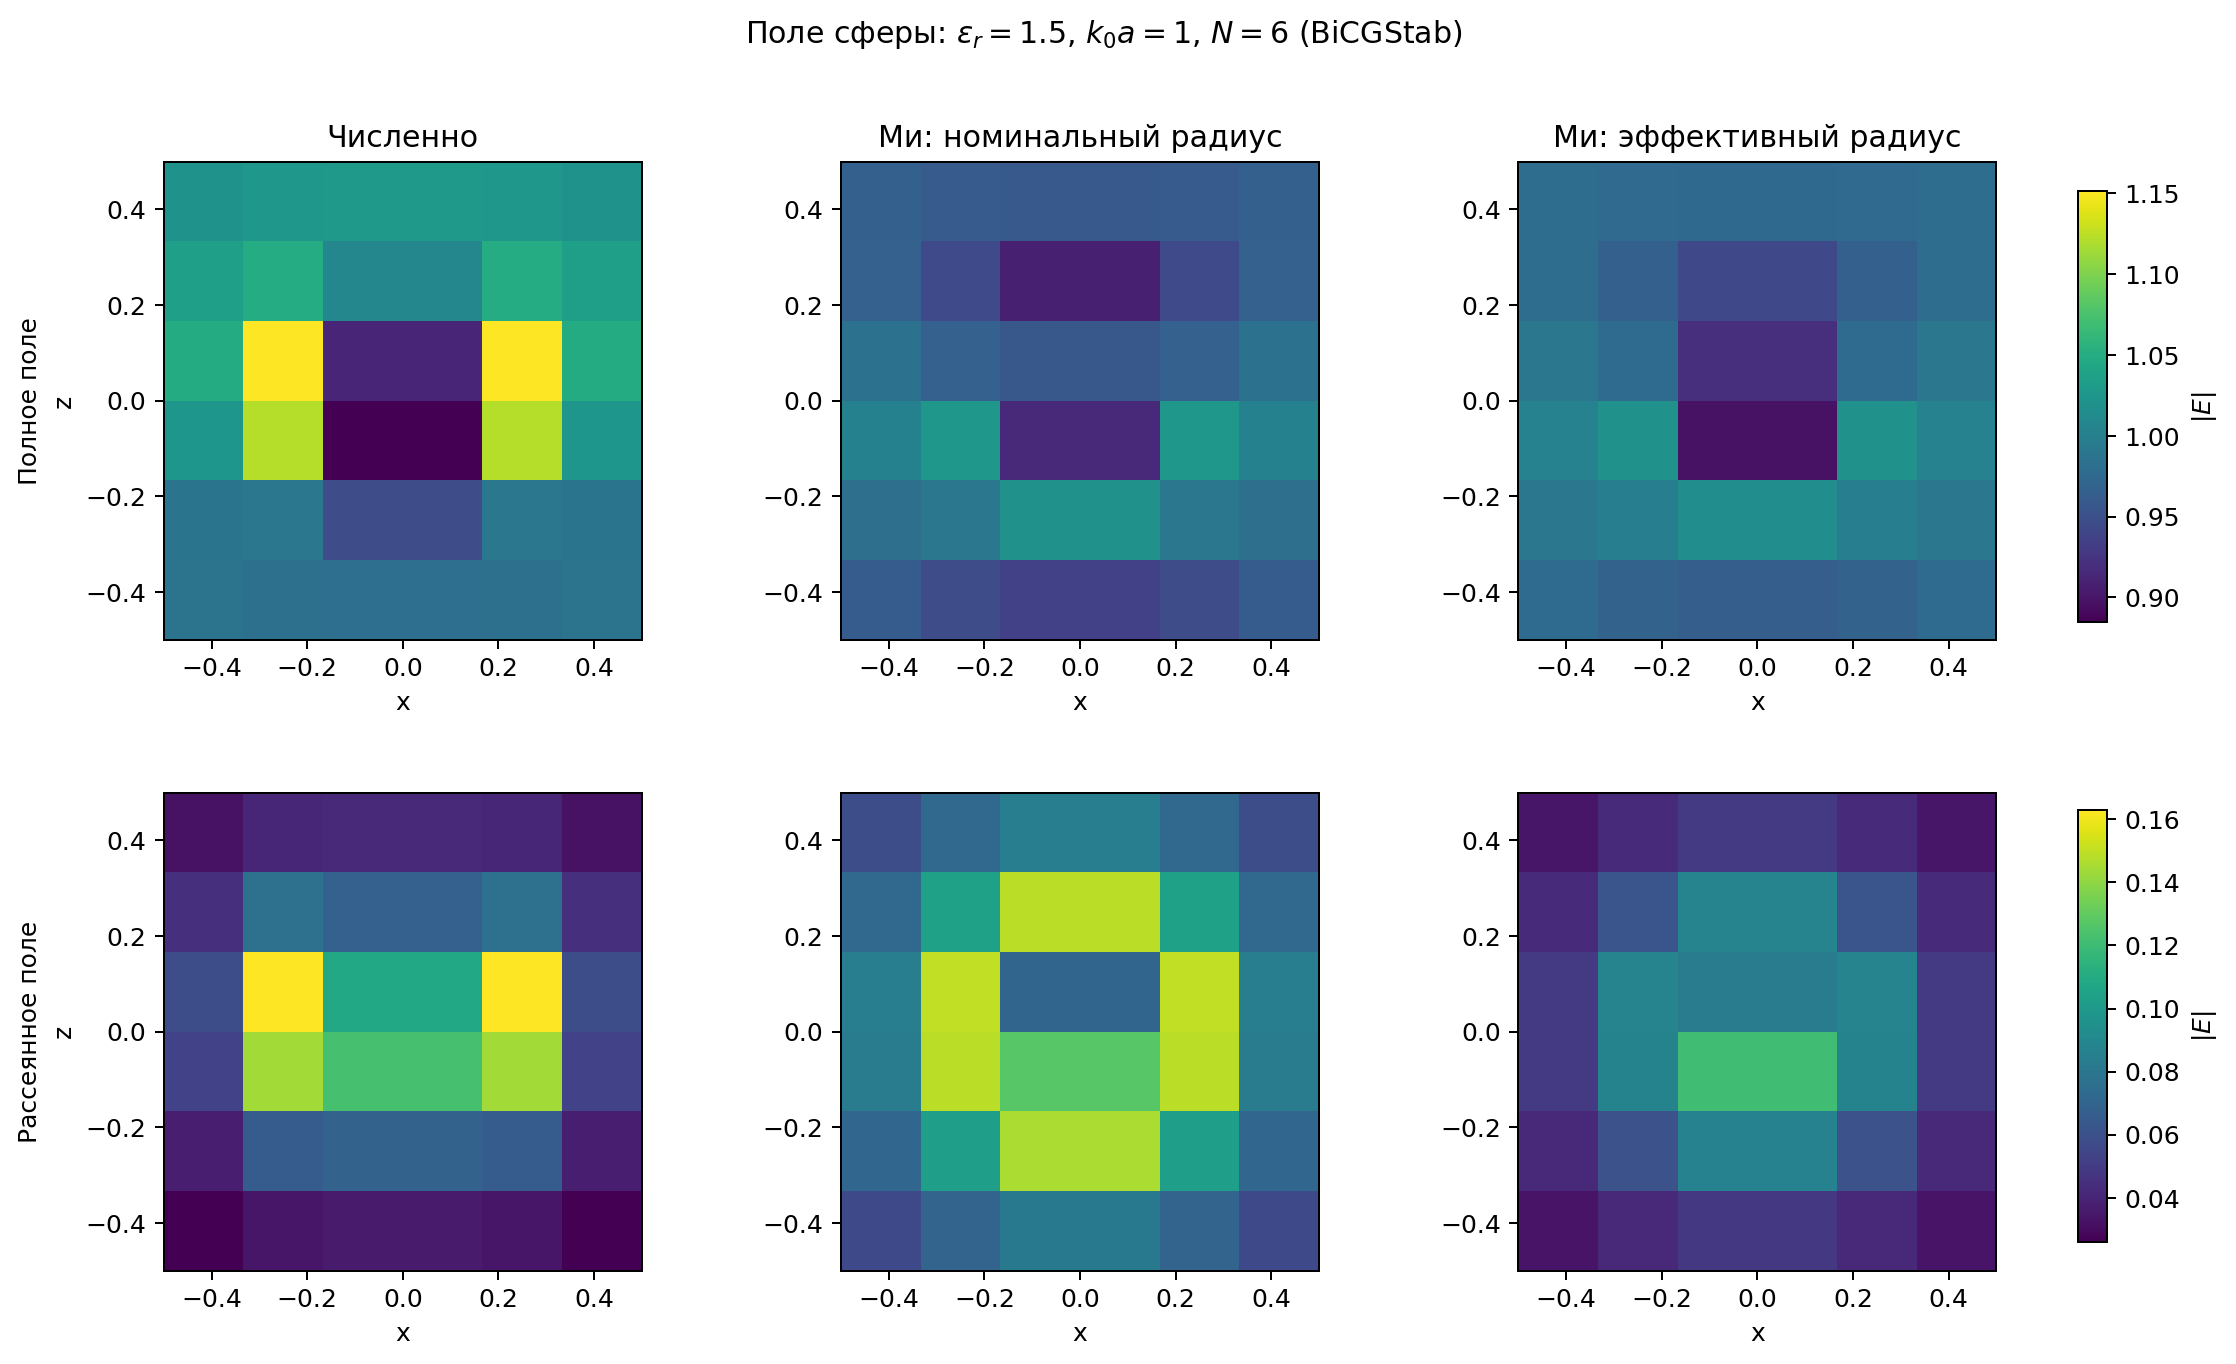

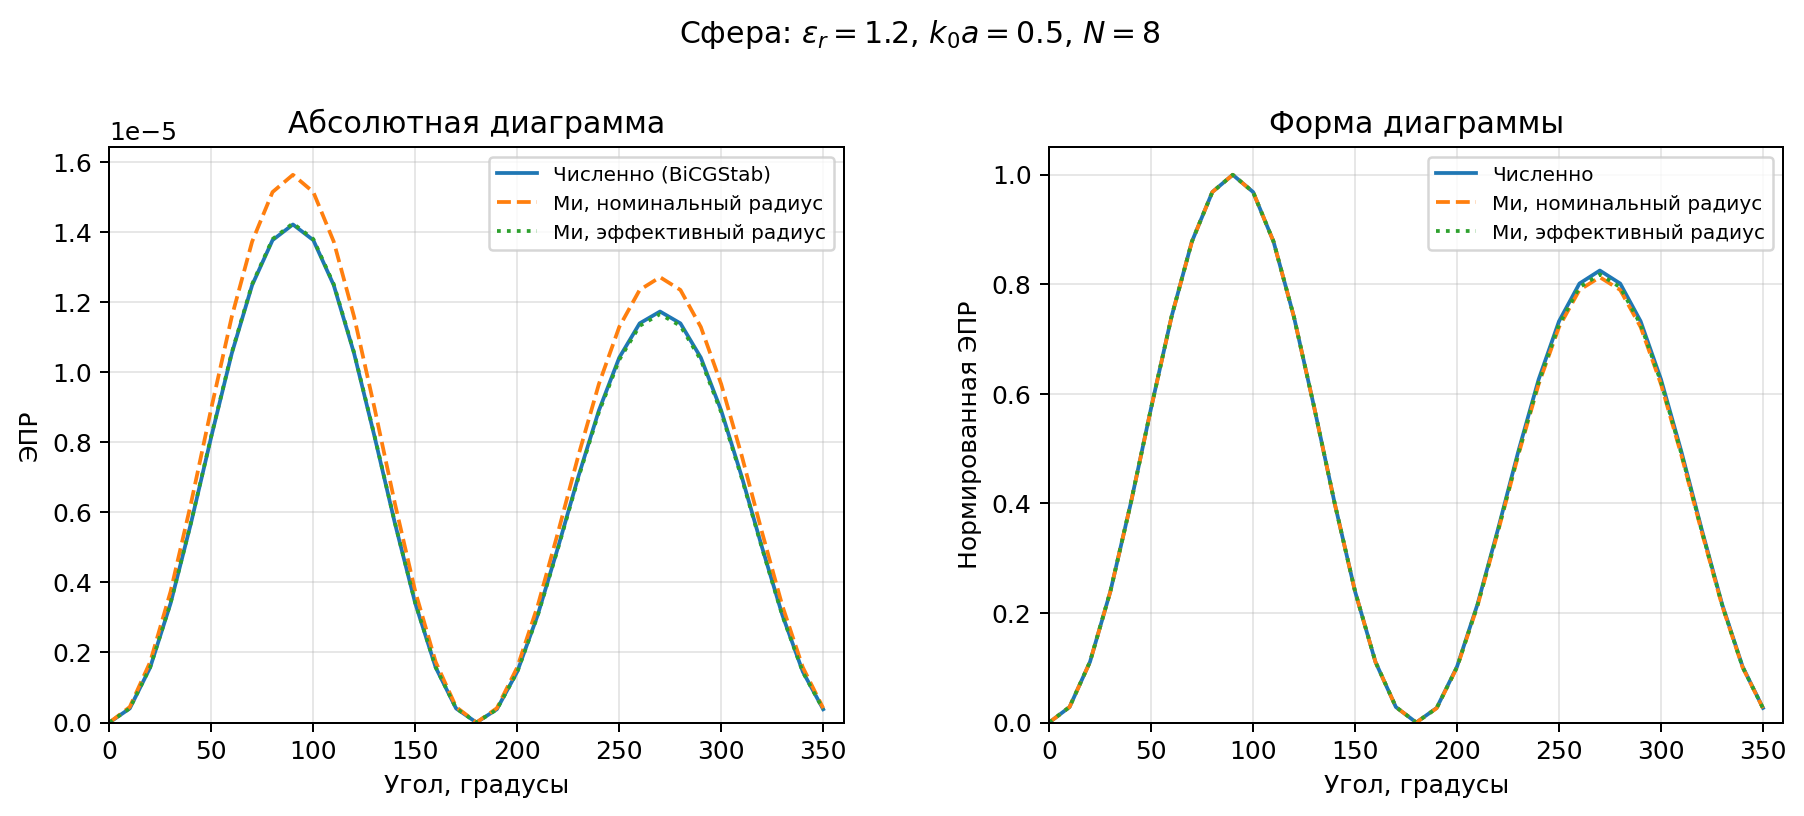

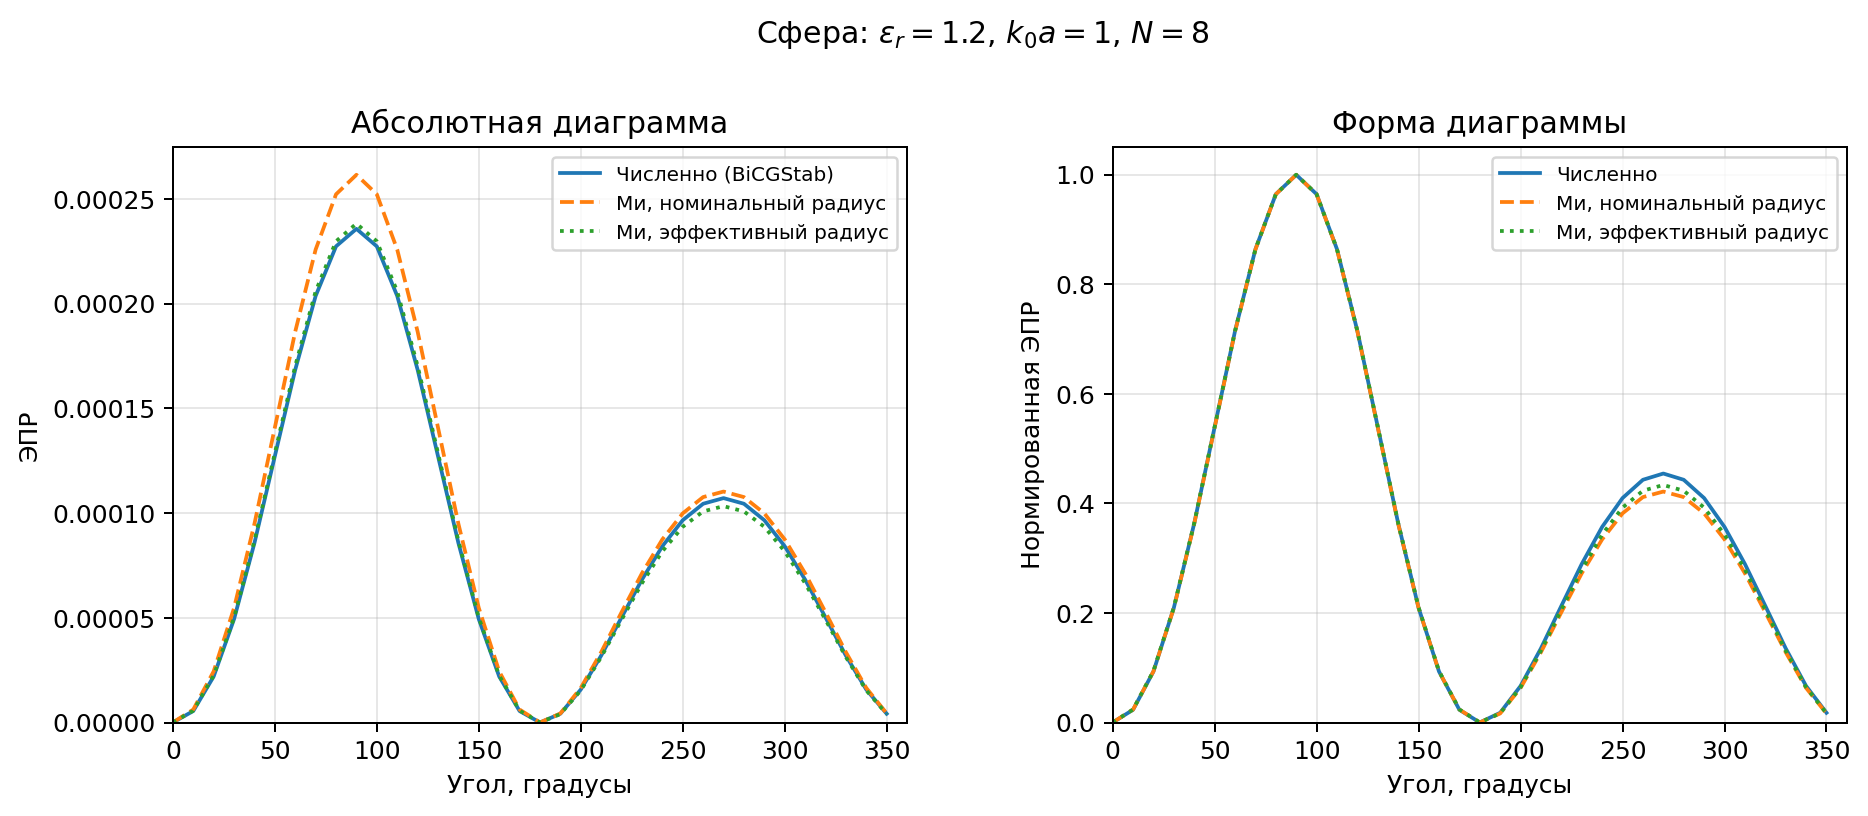

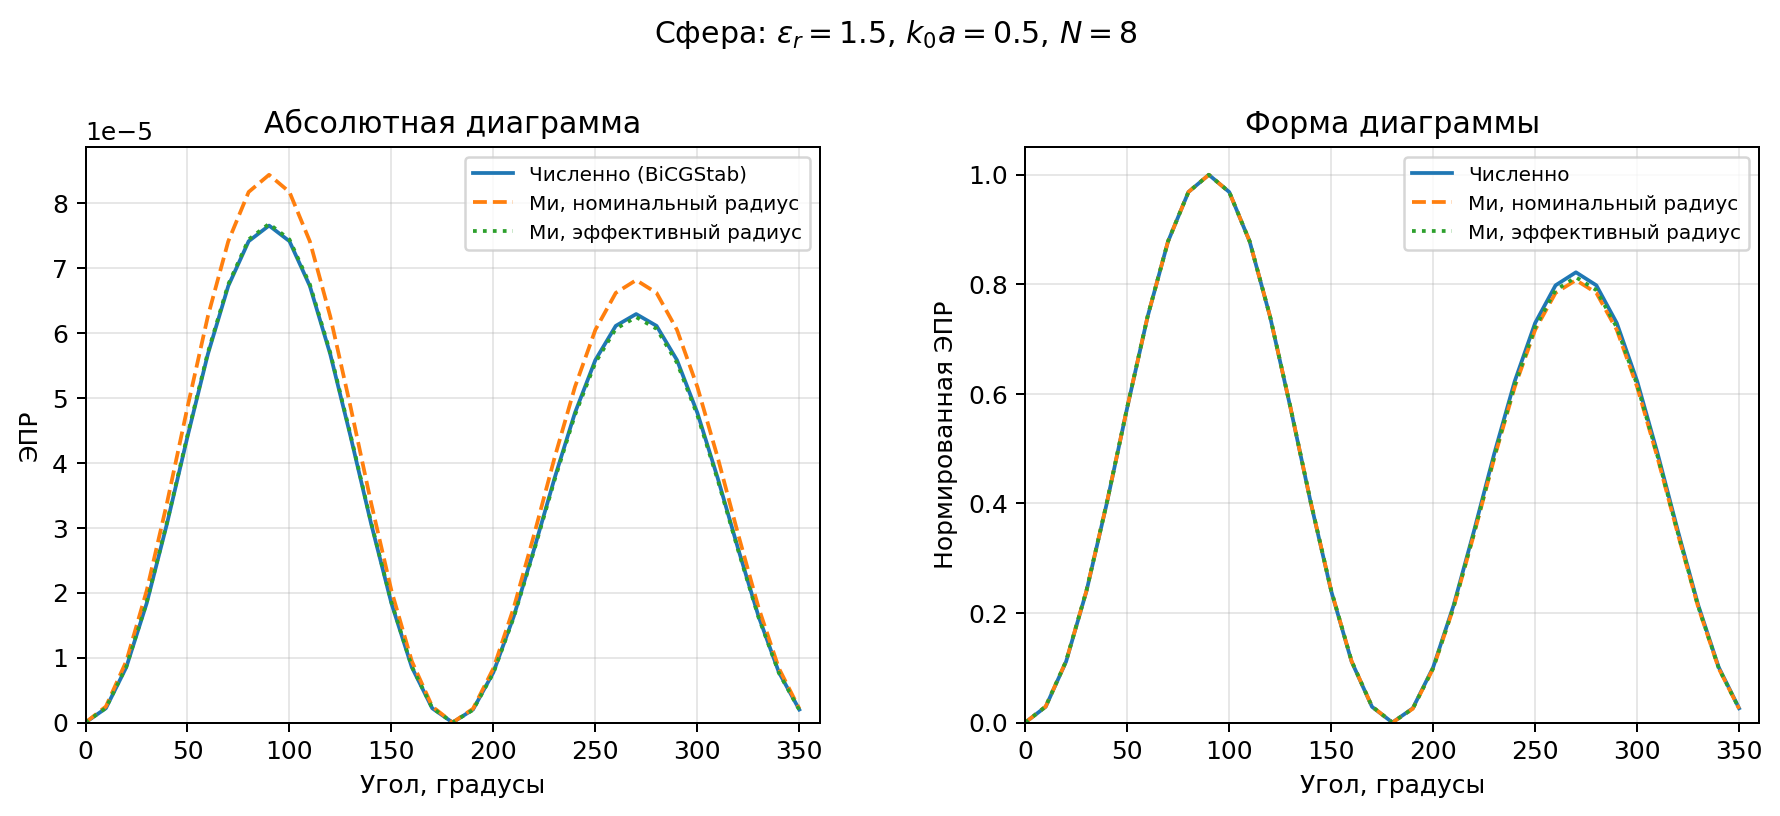

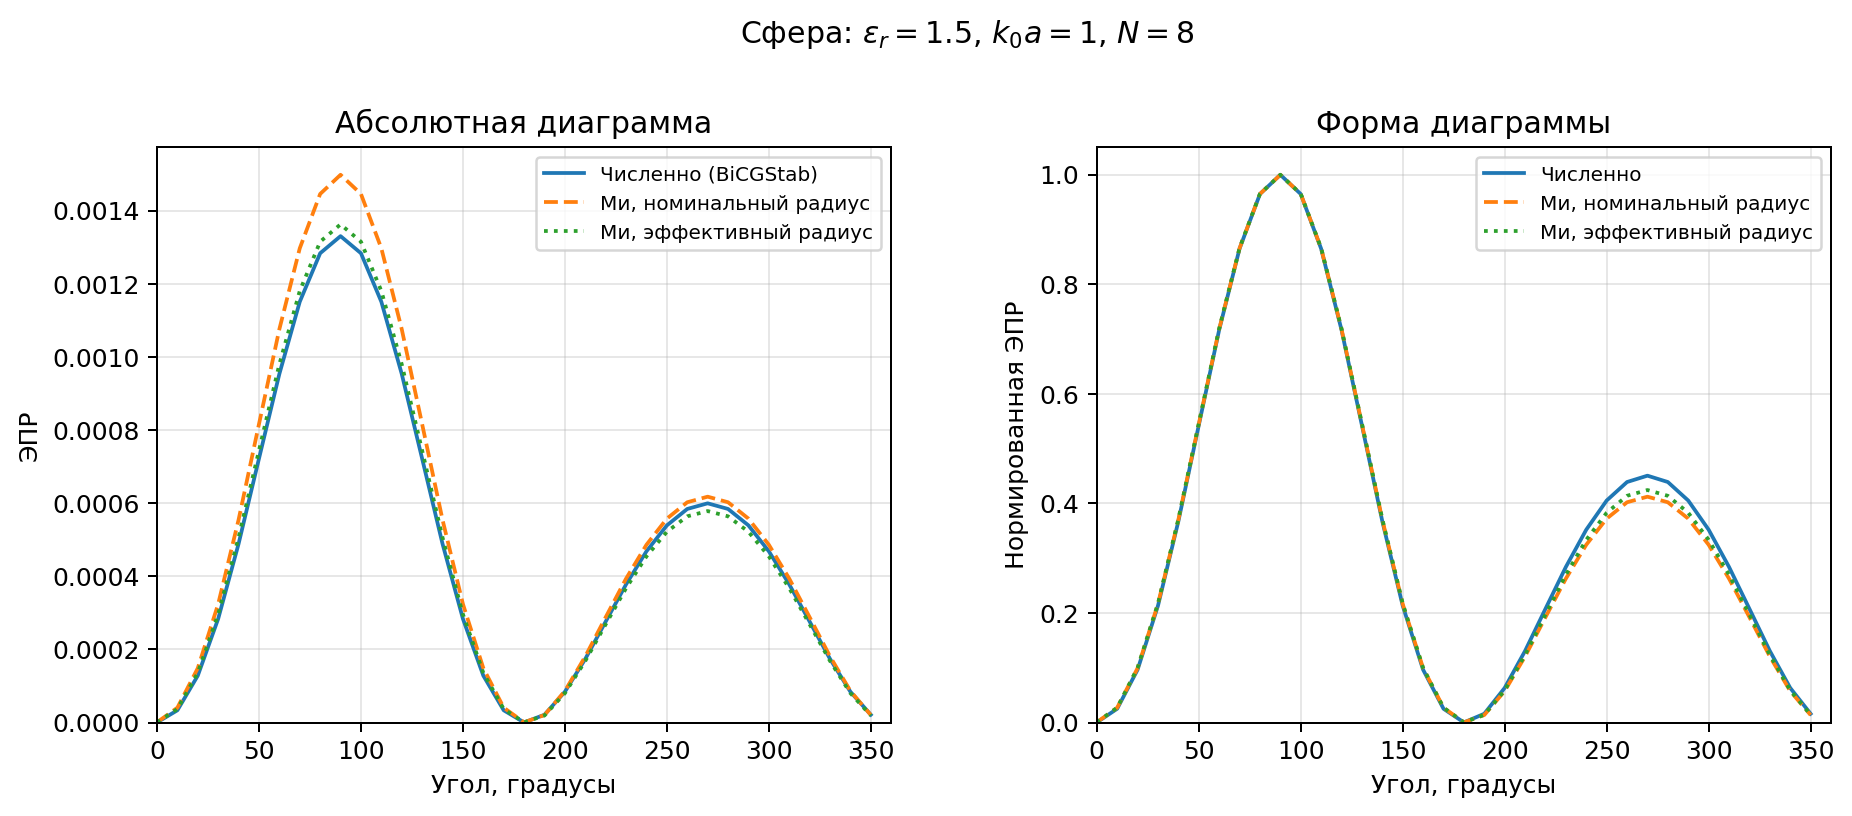

In [10]:
for path in sorted((OUTPUT_ROOT / "figures" / "mie").glob("*.png")):
    display(Image(filename=str(path)))
for subdirectory in ("fields", "curves"):
    for path in sorted((OUTPUT_ROOT / "figures" / "mie" / subdirectory).glob("*.png")):
        display(Image(filename=str(path)))


## 7. Интерпретационные ограничения

1. Равенство малой невязке является необходимым, но не достаточным условием физической верификации: отдельно контролируются поле и дальняя зона.
2. Сопоставление решателей выполняется только для запусков, которые действительно достигли заданной истинной относительной невязки. Несошедшиеся решения не используются как равноправные физические результаты.
3. Для сферической задачи приводятся аналитические результаты как для номинального, так и для эффективного радиуса, восстановленного по объёму воксельного тела. Это позволяет разделять ошибку геометрического представления и ошибку численного решения.
4. В публикационном режиме сетки и диапазоны параметров существенно крупнее; быстрый режим служит контрактной и регрессионной проверкой, а не источником окончательных диссертационных чисел.

## 8. Состав сохранённых артефактов

In [11]:
artifacts = pd.DataFrame(manifest["artifacts"])
display(artifacts.groupby("kind").size().rename("count").to_frame())
display(artifacts.head(20))


,count
kind,
csv,8
json,28
npz,34
pdf,19
png,19
svg,19


,path,kind,sha256,bytes
0,config.json,json,4abdaec3178c4feaaf59df0e1d1a737b4dfe64e82473ce...,1223
1,raw/residual_histories/solver/anisotropic_elli...,json,f05c4350c5d8c5902a1c52fb2d4a458b061419d54b1da3...,686
2,raw/solutions/solver/anisotropic_ellipsoid_SIM...,npz,820186182be6e31aa18a446ca45fb503c20abf35382270...,10912
3,raw/residual_histories/solver/anisotropic_elli...,json,31d61584cdae042a5238533434fa5beee3943e5c7da974...,418
4,raw/solutions/solver/anisotropic_ellipsoid_BiC...,npz,253428e4f5992c88bff3fec8b74273df2031227cd2d873...,10828
5,raw/residual_histories/solver/anisotropic_elli...,json,c640395835cbbb5700b28cf82f50ef9741541ed36c628b...,658
6,raw/solutions/solver/anisotropic_ellipsoid_Two...,npz,a543e085d95750741a1a9aa0ca8f54c19585eaae8142f5...,10900
7,raw/rcs/solver/anisotropic_ellipsoid_xz_SIM.npz,npz,23ecac1f1004d36d6454d43d35c9a413b9a10adab94ec1...,1217
8,raw/rcs/solver/anisotropic_ellipsoid_xz_BiCGSt...,npz,4a3da38b92c9e7eadf3615b1cdfcdccd50dd52386ae1d5...,1212
9,raw/rcs/solver/anisotropic_ellipsoid_xz_TwoSte...,npz,51ceae9ad3ea6ec469bd2bf19fe8d98353bcdfed5b5a9e...,1214
